## Install Dependencies

In [1]:
import json
import numpy as np
import os
from pprint import pprint
from statistics import mean, stdev
from typing import List, Dict, Callable

In [2]:
%pip install matplotlib
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 100 # TODO: Change DPI before submitting paper.


[notice] A new release of pip is available: 25.0 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
%pip install pandas
import pandas as pd


[notice] A new release of pip is available: 25.0 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Util functions

In [4]:
def load_json(path: str) -> Dict:
    with open(path, "r") as json_file:
        return json.load(json_file)

In [5]:
def printb(text: str) -> None:
    print("\033[1m" + text + "\033[0m")

### Experiment Dataclass

In [6]:
from dataclasses import dataclass

@dataclass
class Experiment:
    qubit_num: int
    gate_count: int
    target: str

    population_size: int
    max_generations: int
    mutation_prob: float
    crossover_prob: float
    selection_strategy: str

    cache_rebuild_frequency: int
    cache_size: int
    merging_rounds: int

    source_paths: List[str]
    seeds: List[int]

    tag: str
    label: str

    data_per_seed: List[pd.DataFrame]

    fitness_scores: pd.DataFrame
    redundancies: pd.DataFrame
    simulation_durations: pd.DataFrame
    cache_utilizations: pd.DataFrame

    def __hash__(self) -> str:
        key = f"{self.qubit_num}q{self.gate_count}g{self.target}st"
        key += f"{self.population_size}p{self.max_generations}mg{self.mutation_prob}mp"
        key += f"{self.crossover_prob}cp{self.selection_strategy}s"
        key += f"{self.cache_rebuild_frequency}crf{self.cache_size}cs{self.merging_rounds}mr"
        key += f"{self.tag}t"
        return hash(key)
    
    def __eq__(self, value: "Experiment"):
        return self.__hash__() == value.__hash__()
    
    @property
    def config(self):
        return {
            "qubit_num": self.qubit_num,
            "gate_count": self.gate_count,
            "target": self.target,
            "population_size": self.population_size,
            "max_generations": self.max_generations,
            "mutation_prob": self.mutation_prob,
            "crossover_prob": self.crossover_prob,
            "selection_strategy": self.selection_strategy,
            "cache_rebuild_frequency": self.cache_rebuild_frequency,
            "cache_size": self.cache_size,
            "merging_rounds": self.merging_rounds,
            "tag": self.tag,
            "seeds": sorted(self.seeds)
        }


### Filter experiments

In [7]:
def filter_experiments(experiments: List[Experiment], filter_params: Dict, sort_by: str = "qubit_num") -> List:

    filtered_experiments: List[Experiment] = []
    for experiment in experiments:

        for key, value in filter_params.items():
            
            if experiment.__dict__[key] != value:
                break 

        else:
            filtered_experiments.append(experiment)                 


    filtered_experiments.sort(key=lambda item: item.__dict__[sort_by])
    return filtered_experiments

### Merge Dataframes

In [8]:
def merge_fitness_dfs(dfs: List[pd.DataFrame]) -> pd.DataFrame:
    total_df = pd.concat(dfs)

    avg_best = total_df.groupby("generation")["fitness_#0"].mean()
    median_best = total_df.groupby("generation")["fitness_#0"].median()
    std_best = total_df.groupby("generation")["fitness_#0"].std()

    merged_df = pd.concat([avg_best, median_best, std_best], keys=[
                          "avg_best_fitness", "median_best_fitness", "std_best_fitness"], axis=1)
    merged_df = merged_df.reset_index()
    merged_df.fillna(0, inplace=True)

    return merged_df

In [9]:
def merge_redundancy_dfs(dfs: List[pd.DataFrame]) -> pd.DataFrame:
    total_df = pd.concat(dfs)

    avg_redundancy = total_df.groupby("generation")["population_redundancy"].mean()
    median_redundancy = total_df.groupby("generation")["population_redundancy"].median()
    std_redundancy = total_df.groupby("generation")["population_redundancy"].std()

    merged_df = pd.concat([avg_redundancy, median_redundancy, std_redundancy], keys=[
                          "avg_redundancy", "median_redundancy", "std_redundancy"], axis=1)
    merged_df = merged_df.reset_index()
    merged_df.fillna(0, inplace=True)

    return merged_df

In [10]:
def merge_simulation_dfs(dfs: List[pd.DataFrame]) -> pd.DataFrame:
    total_df = pd.concat(dfs)

    avg_build_cache_duration = total_df.groupby(
        "generation")["build_cache_duration"].mean()
    median_build_cache_duration = total_df.groupby(
        "generation")["build_cache_duration"].median()
    std_build_cache_duration = total_df.groupby(
        "generation")["build_cache_duration"].std()

    avg_simulate_duration = total_df.groupby(
        "generation")["simulate_duration"].mean()
    median_simulate_duration = total_df.groupby(
        "generation")["simulate_duration"].median()
    std_simulate_duration = total_df.groupby(
        "generation")["simulate_duration"].std()

    avg_total_duration = total_df.groupby(
        "generation")["total_duration"].mean()
    median_total_duration = total_df.groupby(
        "generation")["total_duration"].median()
    std_total_duration = total_df.groupby(
        "generation")["total_duration"].std()

    avg_cum_duration = total_df.groupby(
        "generation")["cum_duration"].mean()
    median_cum_duration = total_df.groupby(
        "generation")["cum_duration"].median()
    std_cum_duration = total_df.groupby(
        "generation")["cum_duration"].std()

    merged_df = pd.concat([avg_build_cache_duration, median_build_cache_duration, std_build_cache_duration, avg_simulate_duration, median_simulate_duration, std_simulate_duration,
                           avg_total_duration, median_total_duration, std_total_duration, avg_cum_duration, median_cum_duration, std_cum_duration
                           ], keys=[
                          "avg_build_cache_duration", "median_build_cache_duration", "std_build_cache_duration", "avg_simulate_duration", "median_simulate_duration", "std_simulate_duration",
                          "avg_total_duration", "median_total_duration", "std_total_duration", "avg_cum_duration", "median_cum_duration", "std_cum_duration"
                          ], axis=1)
    merged_df = merged_df.reset_index()
    merged_df.fillna(0, inplace=True)

    return merged_df

In [11]:
def merge_cache_utilization_dfs(dfs: List[pd.DataFrame]) -> pd.DataFrame:
    total_df = pd.concat(dfs)

    avg_cache_hits = total_df.groupby(
        "generation")["cache_hits"].mean()
    median_cache_hits = total_df.groupby(
        "generation")["cache_hits"].median()
    std_cache_hits = total_df.groupby(
        "generation")["cache_hits"].std()

    avg_bigram_hit_count = total_df.groupby(
        "generation")["bigram_hit_count"].mean()
    median_bigram_hit_count = total_df.groupby(
        "generation")["bigram_hit_count"].median()
    std_bigram_hit_count = total_df.groupby(
        "generation")["bigram_hit_count"].std()

    avg_cache_hit_length = total_df.groupby(
        "generation")["average_cache_hit_length"].mean()
    median_cache_hit_length = total_df.groupby(
        "generation")["average_cache_hit_length"].median()
    std_cache_hit_length = total_df.groupby(
        "generation")["average_cache_hit_length"].std()

    avg_cum_cache_hits = total_df.groupby(
        "generation")["cum_cache_hits"].mean()
    median_cum_cache_hits = total_df.groupby(
        "generation")["cum_cache_hits"].median()
    std_cum_cache_hits = total_df.groupby(
        "generation")["cum_cache_hits"].std()

    avg_bigram_share = total_df.groupby(
        "generation")["bigram_share"].mean()
    median_bigram_share = total_df.groupby(
        "generation")["bigram_share"].median()
    std_bigram_share = total_df.groupby(
        "generation")["bigram_share"].std()

    merged_df = pd.concat([avg_cache_hits, median_cache_hits, std_cache_hits, avg_bigram_hit_count, median_bigram_hit_count, std_bigram_hit_count, avg_cache_hit_length, median_cache_hit_length, std_cache_hit_length,
                           avg_cum_cache_hits, median_cum_cache_hits, std_cum_cache_hits, avg_bigram_share, median_bigram_share, std_bigram_share
                           ], keys=[
                          "avg_cache_hits", "median_cache_hits", "std_cache_hits", "avg_bigram_hit_count", "median_bigram_hit_count", "std_bigram_hit_count", "avg_cache_hit_length", "median_cache_hit_length", "std_cache_hit_length",
                          "avg_cum_cache_hits", "median_cum_cache_hits", "std_cum_cache_hits", "avg_bigram_share", "median_bigram_share", "std_bigram_share"
                          ], axis=1)
    merged_df = merged_df.reset_index()
    merged_df.fillna(0, inplace=True)

    return merged_df

### Load Experiments

In [12]:
def default_label_function(experiment: Experiment) -> str:
    return "TBD"

In [13]:
def extend_experiment_data(df: pd.DataFrame):
    df["total_duration"] = df["build_cache_duration"] + df["simulate_duration"]
    df["cum_duration"] = df["build_cache_duration"].cumsum() + df["simulate_duration"].cumsum()
    df["cum_cache_hits"] = df["cache_hits"].cumsum()
    df["bigram_share"] = df["bigram_hit_count"] / df["cache_hits"] * 100

In [14]:
def load_experiments(results_dir: str = "results", min_generations: int = None) -> List[Experiment]:
    experiments: Dict[str, Experiment] = {}

    for file_name in os.listdir(results_dir):
        # Avoid running into issues with hyperparameter opt results.
        if not file_name.startswith("experiment_"):
            continue

        if not file_name.endswith("_config.json"):
            continue

        config_path = f"{results_dir}/{file_name}"
        config = load_json(config_path)

        path_prefix: str = config["meta"]["results_path_prefix"]
        tag_components = path_prefix.split("_")
        tag = "_".join(tag_components[1:-1])

        data_path = f"{results_dir}/{file_name.replace('_config.json', '_results.csv')}"

        experiment_data = pd.read_csv(data_path, delimiter=";")
        for column in experiment_data.columns:
            experiment_data = experiment_data.rename(columns={
                column: column.strip().replace(" ", "_")
            })
        extend_experiment_data(experiment_data)

        experiment = Experiment(
            qubit_num=config["qubit_num"],
            gate_count=config["gate_count"],
            target=config["target"],

            population_size=config["ga_params"]["population_size"],
            max_generations=config["ga_params"]["max_generations"],
            mutation_prob=config["ga_params"]["mutation_prob"],
            crossover_prob=config["ga_params"]["crossover_prob"],
            selection_strategy=config["ga_params"]["selection_strategy"],

            cache_rebuild_frequency=config["caching_params"]["cache_rebuild_frequency"],
            cache_size=config["caching_params"]["cache_size"],
            merging_rounds=config["caching_params"]["merging_rounds"],

            tag=tag,
            label="TBD",

            source_paths=[
                config_path
            ],

            seeds=[
                config["meta"]["seed"]
            ],

            data_per_seed=[experiment_data],

            fitness_scores=None,
            redundancies=None,
            simulation_durations=None,
            cache_utilizations=None
        )

        if experiment in experiments:
            experiments[experiment].source_paths.append(
                experiment.source_paths[0])
            experiments[experiment].seeds.append(experiment.seeds[0])
            experiments[experiment].data_per_seed.append(
                experiment.data_per_seed[0])
        else:
            experiments[experiment] = experiment

    experiments: List[Experiment] = list(experiments.values())
    for experiment in experiments:
        data_dfs = experiment.data_per_seed
        lengths = [len(df) for df in data_dfs]

        if min_generations is None:
            min_gen_threshold = max(lengths)
        else:
            min_gen_threshold = min_generations

        entries_to_pop = [
            i for i, length in enumerate(lengths) if length < min_gen_threshold
        ]

        for entry_to_pop in reversed(entries_to_pop):
            print(
                f"Excluding fitness of {experiment.source_paths[entry_to_pop]} due to length mismatch ({lengths[entry_to_pop]} vs. {min_gen_threshold}).")

            experiment.source_paths.pop(entry_to_pop)
            experiment.seeds.pop(entry_to_pop)
            experiment.data_per_seed.pop(entry_to_pop)

        experiment.fitness_scores = merge_fitness_dfs(
            experiment.data_per_seed)
        experiment.redundancies = merge_redundancy_dfs(
            experiment.data_per_seed)
        experiment.simulation_durations = merge_simulation_dfs(
            experiment.data_per_seed)
        experiment.cache_utilizations = merge_cache_utilization_dfs(
            experiment.data_per_seed)

    return experiments

In [15]:
def set_labels(experiments: List[Experiment], labels: List[str] = None, label_function=default_label_function) -> None:
    for i, experiment in enumerate(experiments):
        if labels is not None:
            experiment.label = labels[i] 
        else:
            experiment.label = label_function(experiment) 

## Visualization Functions

### GA Progress

In [16]:
def plot_redundancy_per_generation(experiments: List[Experiment], target_path: str = None, plot_std: bool = True) -> None:
    ax = plt.subplot()

    for experiment in experiments:
        df = experiment.redundancies

        ax.plot(df["generation"], df["median_redundancy"], label=experiment.label, linewidth=1)

        if plot_std:
            lower_bound = df["median_redundancy"] - df["std_redundancy"]
            upper_bound = df["median_redundancy"] + df["std_redundancy"]
            ax.fill_between(
                df["generation"], lower_bound, upper_bound, alpha=0.2
            )

    ax.set_ylim(0)

    ax.set_xlabel("generation")

    ax.set_ylabel("population redundancy")

    plt.grid()

    if len(experiments) > 1:
        plt.legend()

    if target_path is not None:
        plt.savefig(target_path, bbox_inches='tight')

    plt.show()
    plt.clf()

In [17]:
def print_redundancy(experiments: List[Experiment]) -> None:
    for experiment in experiments:
        print(f"Mean redundancy for '{experiment.label}': {experiment.redundancies['median_redundancy'].mean()}")

In [18]:
def plot_fitness_per_generation(experiments: List[Experiment], target_path: str = None, plot_std: bool = True, anchor_yaxis: bool = True) -> None:
    ax = plt.subplot()

    for experiment in experiments:
        df = experiment.fitness_scores

        ax.plot(df["generation"], df["median_best_fitness"], label=experiment.label, linewidth=1)

        if plot_std:
            lower_bound = df["median_best_fitness"] - df["std_best_fitness"]
            upper_bound = df["median_best_fitness"] + df["std_best_fitness"]
            ax.fill_between(
                df["generation"], lower_bound, upper_bound, alpha=0.2
            )

    if anchor_yaxis:
        ax.set_ylim(0)

    ax.set_xlabel("generation")

    ax.set_ylabel("best fitness")

    plt.grid()
    
    if len(experiments) > 1:
        plt.legend()

    if target_path is not None:
        plt.savefig(target_path, bbox_inches='tight')
    
    plt.show()
    plt.clf()

### Simulation Time

In [19]:
def plot_net_simulation_time_per_generation(experiments: List[Experiment], target_path: str = None, plot_std: bool = True) -> None:
    ax = plt.subplot()

    for experiment in experiments:
        df = experiment.simulation_durations

        ax.plot(df["generation"], df["median_simulate_duration"], label=experiment.label, linewidth=1)

        if plot_std:
            lower_bound = df["median_simulate_duration"] - df["std_simulate_duration"]
            upper_bound = df["median_simulate_duration"] + df["std_simulate_duration"]
            ax.fill_between(
                df["generation"], lower_bound, upper_bound, alpha=0.2
            )

    ax.set_ylim(0)

    ax.set_xlabel("generation")

    ax.set_ylabel("net simulation time (in sec.)")

    plt.grid()
    
    if len(experiments) > 1:
        plt.legend()

    if target_path is not None:
        plt.savefig(target_path, bbox_inches='tight')
    
    plt.show()
    plt.clf() 

In [20]:
def plot_total_simulation_time_per_generation(experiments: List[Experiment], target_path: str = None, plot_std: bool = True) -> None:
    ax = plt.subplot()

    for experiment in experiments:
        df = experiment.simulation_durations

        ax.plot(df["generation"], df["median_total_duration"], label=experiment.label, linewidth=1)

        if plot_std:
            lower_bound = df["median_total_duration"] - df["std_total_duration"]
            upper_bound = df["median_total_duration"] + df["std_total_duration"]
            ax.fill_between(
                df["generation"], lower_bound, upper_bound, alpha=0.2
            )

    ax.set_ylim(0)

    ax.set_xlabel("generation")

    ax.set_ylabel("total simulation time (in sec.)")

    plt.grid()
    
    if len(experiments) > 1:
        plt.legend()

    if target_path is not None:
        plt.savefig(target_path, bbox_inches='tight')
    
    plt.show()
    plt.clf()  

In [21]:
def plot_cumulative_simulation_time_per_generation(experiments: List[Experiment], target_path: str = None, plot_std: bool = True) -> None:
    
    ax = plt.subplot()

    for experiment in experiments:
        df = experiment.simulation_durations

        ax.plot(df["generation"], df["median_cum_duration"], label=experiment.label, linewidth=1)

        if plot_std:
            lower_bound = df["median_cum_duration"] - df["std_cum_duration"]
            upper_bound = df["median_cum_duration"] + df["std_cum_duration"]
            ax.fill_between(
                df["generation"], lower_bound, upper_bound, alpha=0.2
            )

    ax.set_ylim(0)

    ax.set_xlabel("generation")

    ax.set_ylabel("cumulative simulation time (in sec.)")

    plt.grid()
    
    if len(experiments) > 1:
        plt.legend()

    if target_path is not None:
        plt.savefig(target_path, bbox_inches='tight')
    
    plt.show()
    plt.clf() 

In [22]:
def print_cumulative_simulation_time(experiments: List[Experiment], reference: Experiment = None) -> None:
    for experiment in experiments:
        total_time = experiment.simulation_durations["median_simulate_duration"].sum() + experiment.simulation_durations["median_build_cache_duration"].sum()
        
        if reference is not None:
            reference_time = reference.simulation_durations["median_simulate_duration"].sum() + reference.simulation_durations["median_build_cache_duration"].sum()
            time_savings = (reference_time - total_time) / reference_time

            print(f"Total simulation time for '{experiment.label}': {total_time} (-{round(time_savings * 100, 2)}%)")
        else:
            print(f"Total simulation time for '{experiment.label}': {total_time}")


### Time Savings

In [23]:
def plot_time_savings_per_generation(experiments: List[Experiment], no_cache_experiment: Experiment, target_path: str = None) -> None:
    ax = plt.subplot()

    for experiment in experiments:
        df = experiment.simulation_durations

        ax.plot(df["generation"], 100 * (no_cache_experiment.simulation_durations["median_simulate_duration"] - (df["median_simulate_duration"] + df["median_build_cache_duration"])) / no_cache_experiment.simulation_durations["median_simulate_duration"], label=experiment.label, linewidth=1)


    ax.set_xlabel("generation")

    ax.set_ylabel("time savings (in %)")

    plt.grid()
    
    if len(experiments) > 1:
        plt.legend()

    if target_path is not None:
        plt.savefig(target_path, bbox_inches='tight')
    
    plt.show()
    plt.clf()  

In [24]:
def plot_time_savings_per_cache_hit(experiments: List[Experiment], no_cache_experiment: Experiment, target_path: str = None) -> None:
    ax = plt.subplot()

    for experiment in experiments:
        ax.plot(experiment.simulation_durations["generation"], (no_cache_experiment.simulation_durations["median_simulate_duration"] - (experiment.simulation_durations["median_simulate_duration"] + experiment.simulation_durations["median_build_cache_duration"])) / no_cache_experiment.simulation_durations["median_simulate_duration"] / experiment.cache_utilizations["median_cache_hits"], label=experiment.label, linewidth=1)

    ax.set_ylim(0)

    ax.set_xlabel("generation")

    ax.set_ylabel("time savings (in %) per cache hit")

    plt.grid()
    
    if len(experiments) > 1:
        plt.legend()

    if target_path is not None:
        plt.savefig(target_path, bbox_inches='tight')
    
    plt.show()
    plt.clf()  

### Cache Composition and Use

In [25]:
def plot_cache_hits_per_generation(experiments: List[Experiment], target_path: str = None, plot_std: bool = True) -> None:
    ax = plt.subplot()

    for experiment in experiments:
        df = experiment.cache_utilizations

        ax.plot(df["generation"], df["median_cache_hits"], label=experiment.label, linewidth=1)

        if plot_std:
            lower_bound = df["median_cache_hits"] - df["std_cache_hits"]
            upper_bound = df["median_cache_hits"] + df["std_cache_hits"]
            ax.fill_between(
                df["generation"], lower_bound, upper_bound, alpha=0.2
            )

    ax.set_ylim(0)

    ax.set_xlabel("generation")

    ax.set_ylabel("cache hits")

    plt.grid()
    
    if len(experiments) > 1:
        plt.legend()

    if target_path is not None:
        plt.savefig(target_path, bbox_inches='tight')
    
    plt.show()
    plt.clf()  

In [26]:
def plot_cumulative_cache_hits_per_generation(experiments: List[Experiment], target_path: str = None, plot_std: bool = True) -> None:
    ax = plt.subplot()

    for experiment in experiments:
        df = experiment.cache_utilizations

        ax.plot(df["generation"], df["median_cum_cache_hits"], label=experiment.label, linewidth=1)

        if plot_std:
            lower_bound = df["median_cum_cache_hits"] - df["std_cum_cache_hits"]
            upper_bound = df["median_cum_cache_hits"] + df["std_cum_cache_hits"]
            ax.fill_between(
                df["generation"], lower_bound, upper_bound, alpha=0.2
            )


    ax.set_ylim(0)

    ax.set_xlabel("generation")

    ax.set_ylabel("cumulative cache hits")

    plt.grid()
    
    if len(experiments) > 1:
        plt.legend()

    if target_path is not None:
        plt.savefig(target_path, bbox_inches='tight')
    
    plt.show()
    plt.clf()  

In [27]:
def print_cumulative_cache_hits(experiments: List[Experiment], reference: Experiment = None) -> None:
    for experiment in experiments:
        total_cache_hits = experiment.cache_utilizations["median_cache_hits"].sum()

        if reference is not None:
            reference_hits = reference.cache_utilizations["median_cache_hits"].sum()
            hit_increase = (total_cache_hits - reference_hits) / reference_hits

            print(f"Total cache hits for '{experiment.label}': {total_cache_hits} (+{round(hit_increase * 100, 2)}%)")
        else:
            print(f"Total cache hits for '{experiment.label}': {total_cache_hits}")



In [28]:
def plot_cache_hit_length_per_generation(experiments: List[Experiment], target_path: str = None, plot_std: bool = True) -> None:
    ax = plt.subplot()

    for experiment in experiments:
        df = experiment.cache_utilizations

        ax.plot(df["generation"], df["median_cache_hit_length"], label=experiment.label, linewidth=1)

        if plot_std:
            lower_bound = df["median_cache_hit_length"] - df["std_cache_hit_length"]
            upper_bound = df["median_cache_hit_length"] + df["std_cache_hit_length"]
            ax.fill_between(
                df["generation"], lower_bound, upper_bound, alpha=0.2
            )

    ax.set_ylim(0)

    ax.set_xlabel("generation")

    ax.set_ylabel("cache hit length")

    plt.grid()
    
    if len(experiments) > 1:
        plt.legend()

    if target_path is not None:
        plt.savefig(target_path, bbox_inches='tight')
    
    plt.show()
    plt.clf()  

In [29]:
def print_avg_cache_hit_length(experiments: List[Experiment]) -> None:
    for experiment in experiments:
        avg_cache_hit_length = experiment.cache_utilizations["median_cache_hit_length"].mean()
        print(f"Mean cache hit length for '{experiment.label}': {avg_cache_hit_length}")

In [30]:
def plot_bigram_share_per_generation(experiments: List[Experiment], target_path: str = None, plot_std: bool = True) -> None:
    ax = plt.subplot()

    for experiment in experiments:
        df = experiment.cache_utilizations

        ax.plot(df["generation"], df["median_bigram_share"], label=experiment.label, linewidth=1)

        if plot_std:
            lower_bound = df["median_bigram_share"] - df["std_bigram_share"]
            upper_bound = df["median_bigram_share"] + df["std_bigram_share"]
            ax.fill_between(
                df["generation"], lower_bound, upper_bound, alpha=0.2
            )


    ax.set_ylim(0)

    ax.set_xlabel("generation")

    ax.set_ylabel("cache hits that were bigrams (in %)")

    plt.grid()
    
    if len(experiments) > 1:
        plt.legend()

    if target_path is not None:
        plt.savefig(target_path, bbox_inches='tight')
    
    plt.show()
    plt.clf()  

## RQ 1: Varying Cache Parameters

In [31]:
experiments = load_experiments(
    results_dir="results/results/")

no_cache_experiment = filter_experiments(
    experiments, filter_params={"cache_size": 0, "target": "random", "selection_strategy": "roulette", "qubit_num": 6})[0]
set_labels([no_cache_experiment], labels=["no cache"])

print(f"Seed count for no cache baseline: {len(no_cache_experiment.seeds)}")

Excluding fitness of results/results//experiment_varying_rebuild_frequency_074cb968-2af0-4f9a-9cff-2af1e7ba3bab_config.json due to length mismatch (4129 vs. 5000).
Excluding fitness of results/results//experiment_varying_ga_setup_39d7e04b-62b7-46c3-a91f-25584e06abfc_config.json due to length mismatch (2755 vs. 5000).
Excluding fitness of results/results//experiment_varying_ga_setup_96f368ad-2645-4798-8385-46a4d9b3355e_config.json due to length mismatch (2755 vs. 5000).
Excluding fitness of results/results//experiment_varying_ga_setup_8bd34cc0-2666-44c2-af1f-3b306cfed4fa_config.json due to length mismatch (2723 vs. 5000).
Excluding fitness of results/results//experiment_varying_ga_setup_8cde73d7-741c-4611-a84f-d97a7ad9a7c3_config.json due to length mismatch (2681 vs. 5000).
Excluding fitness of results/results//experiment_varying_ga_setup_edfc5cb1-03df-4d26-a643-f58ab96c1f80_config.json due to length mismatch (2575 vs. 5000).
Excluding fitness of results/results//experiment_varying_ga_s

Best fitness per generation:


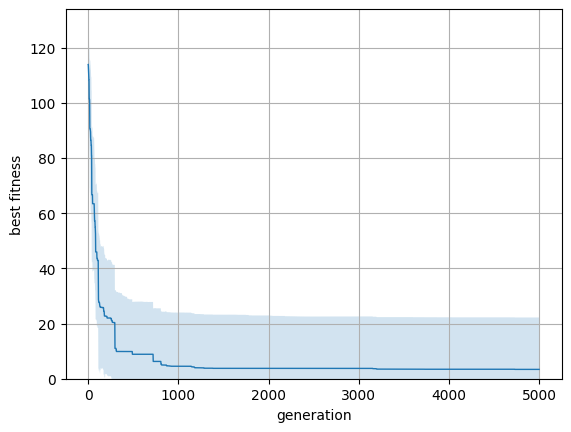

<Figure size 640x480 with 0 Axes>

In [32]:
printb("Best fitness per generation:")
plot_fitness_per_generation([no_cache_experiment], plot_std=True, target_path="results/avg_fitness.png")

Population redundancy per generation:


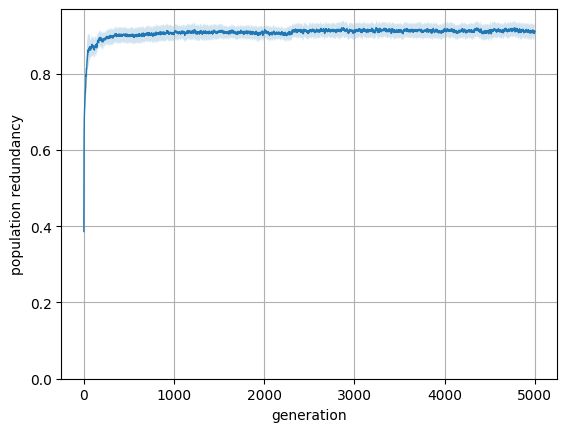

<Figure size 640x480 with 0 Axes>

In [33]:
printb("Population redundancy per generation:")
plot_redundancy_per_generation([no_cache_experiment], plot_std=True, target_path="results/redundancy.png")

### RQ 1.1: Varying Rebuild Frequency

In [34]:
def rebuild_frequency_label(experiment: Experiment) -> str:
    return f"every {experiment.cache_rebuild_frequency} generations"

In [35]:
varying_rebuild_frequency_experiments = filter_experiments(experiments, filter_params={
    "qubit_num": 6,
    "gate_count": 20,
    "cache_size": 100,
    "merging_rounds": 100,
    "target": "random",
    "tag": "varying_rebuild_frequency"
}, sort_by="cache_rebuild_frequency")
set_labels(varying_rebuild_frequency_experiments, label_function=rebuild_frequency_label)

print("Seed counts per config: ")
for experiment in varying_rebuild_frequency_experiments:
    print(f"\t{experiment.label}: {len(experiment.seeds)} seeds")


Seed counts per config: 
	every 1 generations: 13 seeds
	every 10 generations: 14 seeds
	every 50 generations: 14 seeds
	every 250 generations: 15 seeds


Net simulation time per generation:


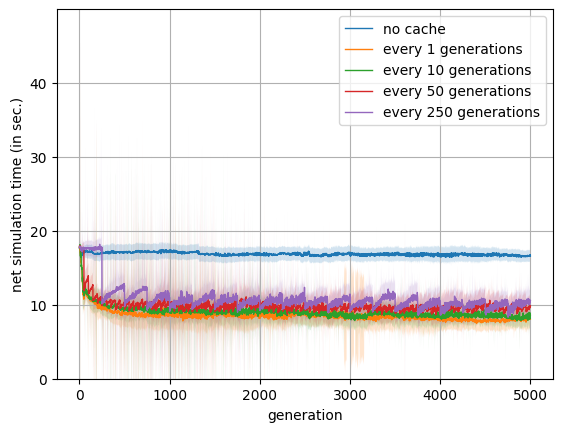

Total simulation time per generation:


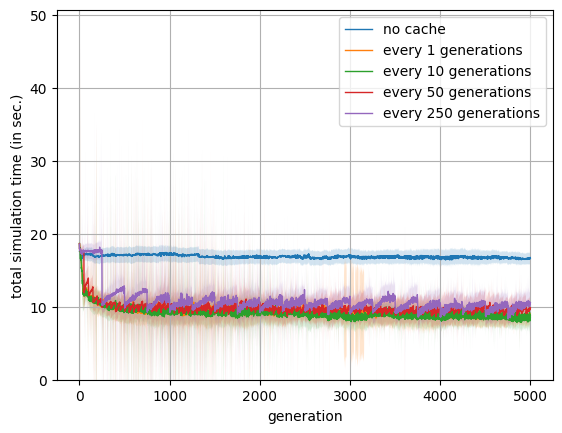

cumulative simulation time:


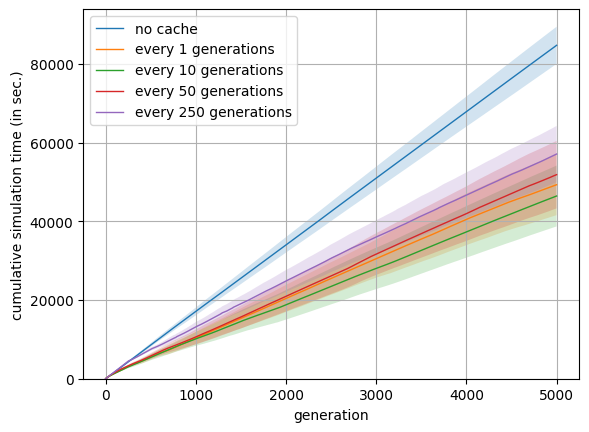

Total simulation time for 'no cache': 84330.718069 (-0.0%)
Total simulation time for 'every 1 generations': 46879.396236 (-44.41%)
Total simulation time for 'every 10 generations': 45525.894447499995 (-46.02%)
Total simulation time for 'every 50 generations': 49425.984418 (-41.39%)
Total simulation time for 'every 250 generations': 53912.403705000004 (-36.07%)


<Figure size 640x480 with 0 Axes>

In [36]:
printb("Net simulation time per generation:")
plot_net_simulation_time_per_generation([no_cache_experiment] + varying_rebuild_frequency_experiments, target_path="results/net_time_different_rf.png")

printb("Total simulation time per generation:")
plot_total_simulation_time_per_generation([no_cache_experiment] + varying_rebuild_frequency_experiments, target_path="results/total_time_different_rf.png")

printb("cumulative simulation time:")
plot_cumulative_simulation_time_per_generation([no_cache_experiment] + varying_rebuild_frequency_experiments, target_path="results/cum_time_different_rf.png")
print_cumulative_simulation_time([no_cache_experiment] + varying_rebuild_frequency_experiments, reference=no_cache_experiment)

Cache hits per generation:


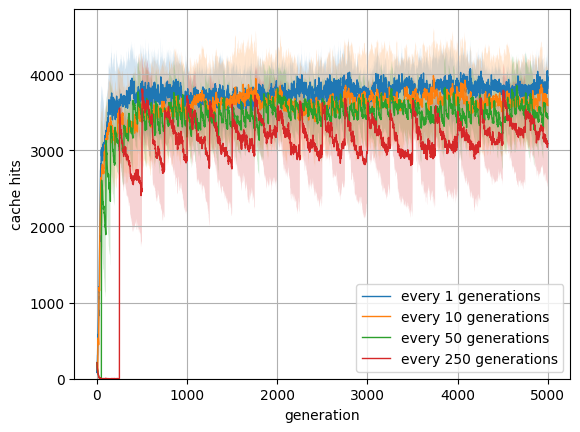

cumulative cache hits:


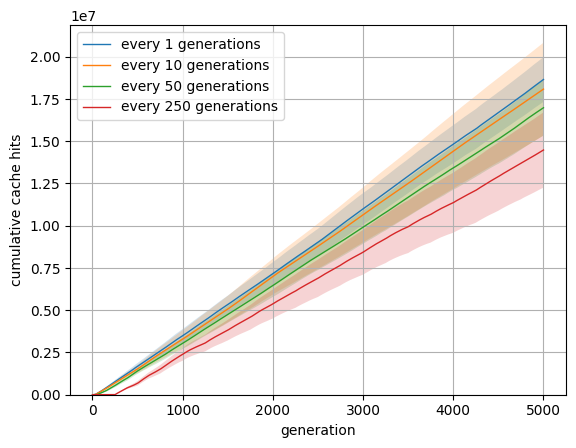

Total cache hits for 'every 1 generations': 18643358.0
Total cache hits for 'every 10 generations': 17868514.0
Total cache hits for 'every 50 generations': 17146563.0
Total cache hits for 'every 250 generations': 15093762.0


<Figure size 640x480 with 0 Axes>

In [37]:
printb("Cache hits per generation:")
plot_cache_hits_per_generation(varying_rebuild_frequency_experiments, target_path="results/hits_different_rf.png")

printb("cumulative cache hits:")
plot_cumulative_cache_hits_per_generation(varying_rebuild_frequency_experiments, target_path="results/cum_hits_different_rf.png")
print_cumulative_cache_hits(varying_rebuild_frequency_experiments)

Average cache hit length:


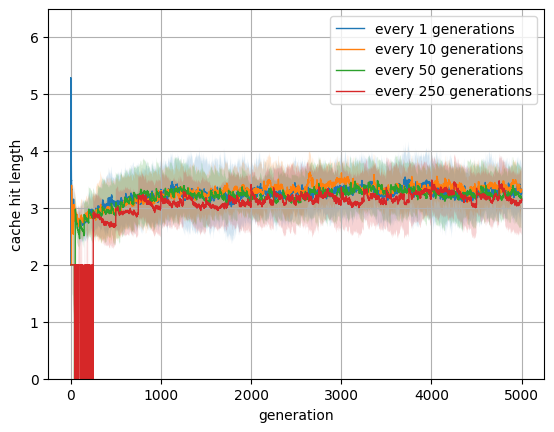

Share of bigrams:


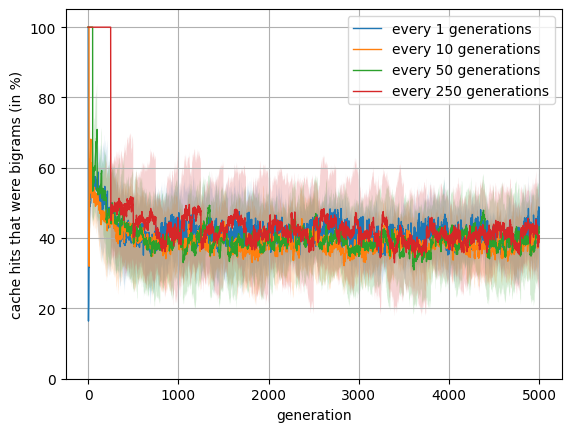

<Figure size 640x480 with 0 Axes>

In [38]:
printb("Average cache hit length:")
plot_cache_hit_length_per_generation(varying_rebuild_frequency_experiments, target_path="results/hit_length_different_rf.png")

printb("Share of bigrams:")
plot_bigram_share_per_generation(varying_rebuild_frequency_experiments, target_path="results/bigram_share_different_rf.png")

### RQ 1.2: Varying Merging Rounds

In [39]:
def rebuild_mr_label(experiment: Experiment) -> str:
    return f"{experiment.merging_rounds} merging rounds"

In [40]:
varying_merging_rounds_experiments = filter_experiments(experiments, filter_params={
    "qubit_num": 6,
    "gate_count": 20,
    "target": "random",
    "tag": "varying_merging_rounds"
}, sort_by="merging_rounds")
set_labels(varying_merging_rounds_experiments + [no_cache_experiment], label_function=rebuild_mr_label)

print("Seed counts per config: ")
for experiment in varying_merging_rounds_experiments:
    print(f"\t{experiment.label}: {len(experiment.seeds)} seeds")


Seed counts per config: 
	0 merging rounds: 10 seeds
	10 merging rounds: 10 seeds
	100 merging rounds: 10 seeds
	1000 merging rounds: 10 seeds


Net simulation time per generation:


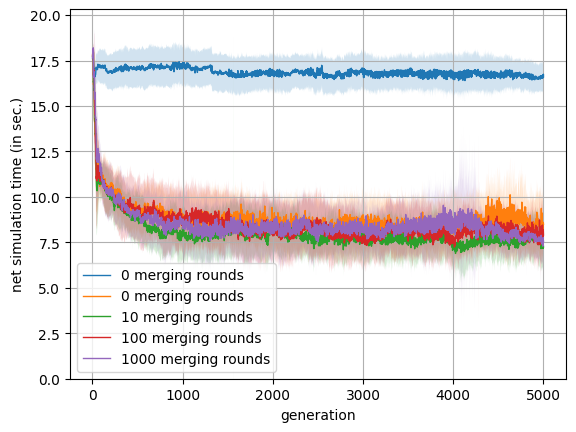

Total simulation time per generation:


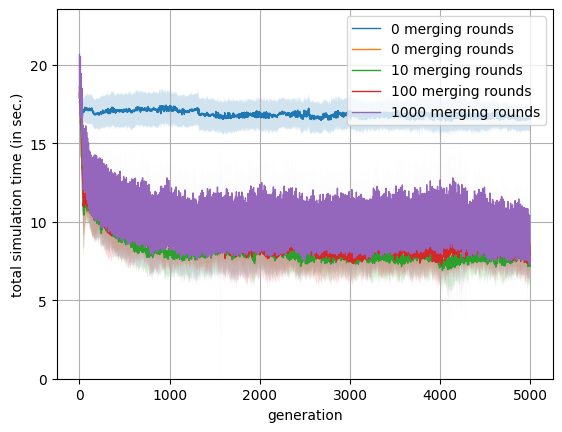

cumulative simulation time:


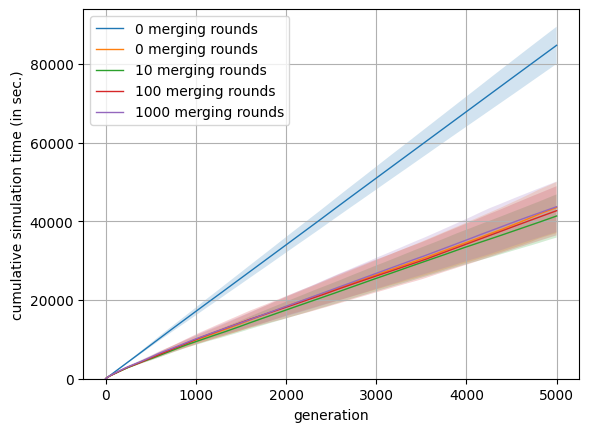

Total simulation time for '0 merging rounds': 84330.718069 (-0.0%)
Total simulation time for '0 merging rounds': 44223.383272499996 (-47.56%)
Total simulation time for '10 merging rounds': 40558.8343145 (-51.91%)
Total simulation time for '100 merging rounds': 42728.1129565 (-49.33%)
Total simulation time for '1000 merging rounds': 44197.37247300001 (-47.59%)


<Figure size 640x480 with 0 Axes>

In [41]:
printb("Net simulation time per generation:")
plot_net_simulation_time_per_generation([no_cache_experiment] + varying_merging_rounds_experiments, target_path="results/net_time_different_mr.png")

printb("Total simulation time per generation:")
plot_total_simulation_time_per_generation([no_cache_experiment] + varying_merging_rounds_experiments, target_path="results/total_time_different_mr.png")

printb("cumulative simulation time:")
plot_cumulative_simulation_time_per_generation([no_cache_experiment] + varying_merging_rounds_experiments, target_path="results/cum_time_different_mr.png") 
print_cumulative_simulation_time([no_cache_experiment] + varying_merging_rounds_experiments, reference=no_cache_experiment)

Average cache hit length:


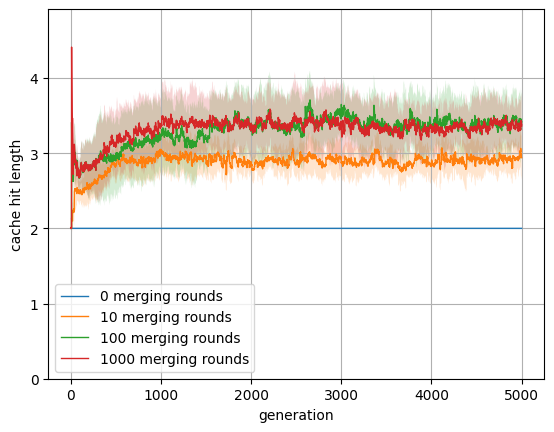

Share of bigrams:


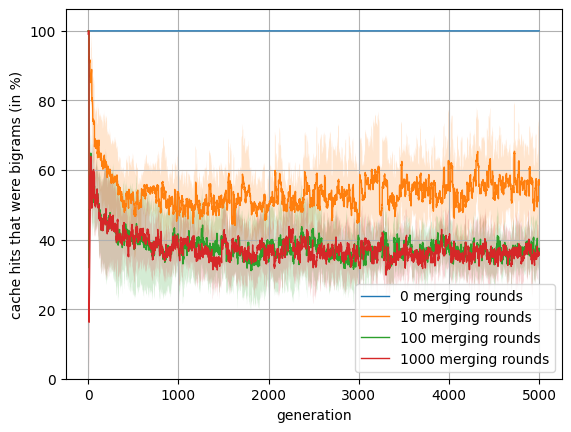

<Figure size 640x480 with 0 Axes>

In [42]:
printb("Average cache hit length:")
plot_cache_hit_length_per_generation(varying_merging_rounds_experiments, target_path="results/hit_length_different_mr.png")

printb("Share of bigrams:")
plot_bigram_share_per_generation(varying_merging_rounds_experiments, target_path="results/bigram_share_different_mr.png")

### RQ 1.3 Varying Cache Size

In [43]:
def rebuild_cs_label(experiment: Experiment) -> str:
    return f"cache size = {experiment.cache_size}"

In [44]:
varying_cache_size_experiments = filter_experiments(experiments, filter_params={
    "qubit_num": 6,
    "gate_count": 20,
    "merging_rounds": 10,
    "cache_rebuild_frequency": 10,
    "target": "random",
    "selection_strategy": "roulette",
}, sort_by="cache_size")
set_labels(varying_cache_size_experiments, label_function=rebuild_cs_label)

varying_cache_size_experiments = varying_cache_size_experiments[1:] # TODO: Once experiments are done, fix jsons and remove this line.

print("Seed counts per config: ")
for experiment in varying_cache_size_experiments:
    print(f"\t{experiment.label}: {len(experiment.seeds)} seeds")


Seed counts per config: 
	cache size = 100: 3 seeds
	cache size = 100: 10 seeds
	cache size = 500: 7 seeds


Net simulation time per generation:


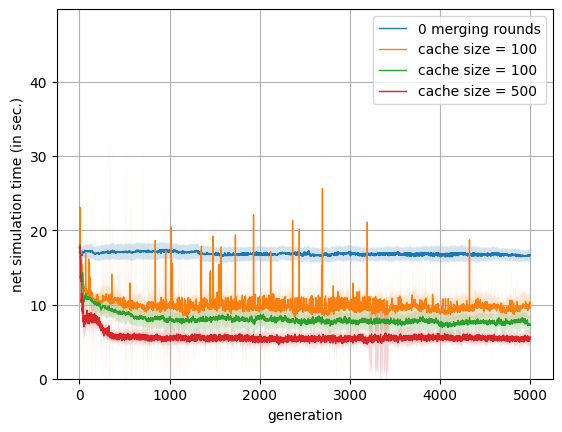

Total simulation time per generation:


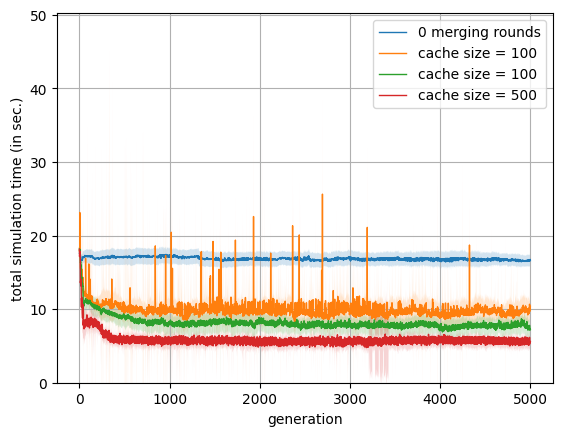

cumulative simulation time:


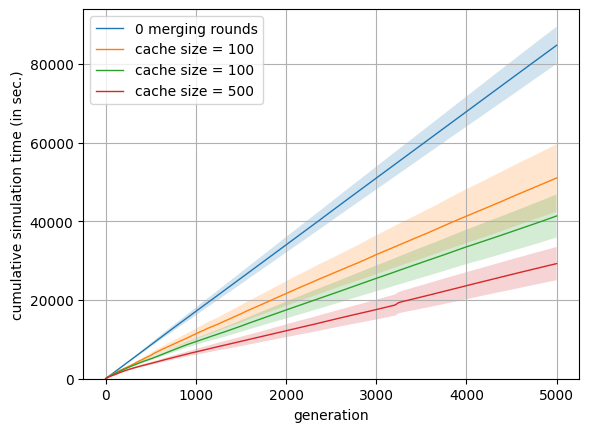

Total simulation time for '0 merging rounds': 84330.718069 (-0.0%)
Total simulation time for 'cache size = 100': 49127.693956 (-41.74%)
Total simulation time for 'cache size = 100': 40558.8343145 (-51.91%)
Total simulation time for 'cache size = 500': 28805.86307 (-65.84%)


<Figure size 640x480 with 0 Axes>

In [45]:
printb("Net simulation time per generation:")
plot_net_simulation_time_per_generation([no_cache_experiment] + varying_cache_size_experiments, target_path="results/net_time_different_cs.png")

printb("Total simulation time per generation:")
plot_total_simulation_time_per_generation([no_cache_experiment] + varying_cache_size_experiments, target_path="results/total_time_different_cs.png")

printb("cumulative simulation time:")
plot_cumulative_simulation_time_per_generation([no_cache_experiment] + varying_cache_size_experiments, target_path="results/cum_time_different_cs.png") 
print_cumulative_simulation_time([no_cache_experiment] + varying_cache_size_experiments, reference=no_cache_experiment)

Cache hits per generation:


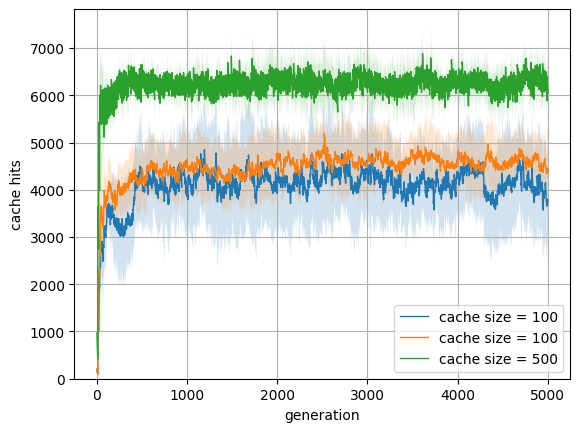

cumulative cache hits:


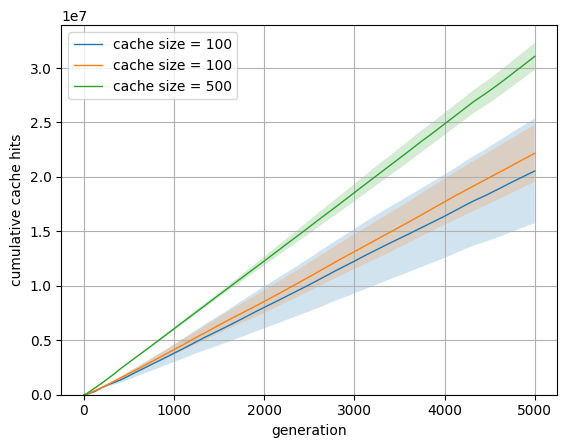

Total cache hits for 'cache size = 100': 20439941.0 (+0.0%)
Total cache hits for 'cache size = 100': 22347474.5 (+9.33%)
Total cache hits for 'cache size = 500': 31021973.0 (+51.77%)


<Figure size 640x480 with 0 Axes>

In [46]:
printb("Cache hits per generation:")
plot_cache_hits_per_generation(varying_cache_size_experiments, target_path="results/hits_different_cs.png")

printb("cumulative cache hits:")
plot_cumulative_cache_hits_per_generation(varying_cache_size_experiments, target_path="results/cum_hits_different_cs.png")
print_cumulative_cache_hits(varying_cache_size_experiments, varying_cache_size_experiments[0])

Average cache hit length:


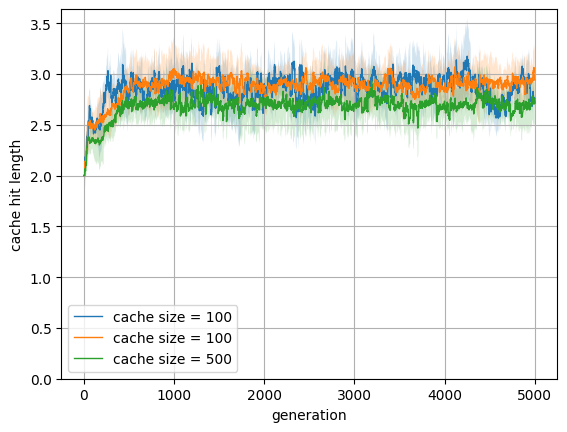

Share of bigrams:


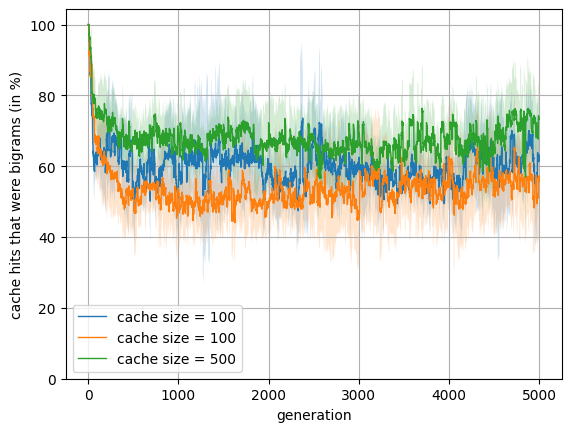

<Figure size 640x480 with 0 Axes>

In [47]:
printb("Average cache hit length:")
plot_cache_hit_length_per_generation(varying_cache_size_experiments, target_path="results/hit_length_different_cs.png")

printb("Share of bigrams:")
plot_bigram_share_per_generation(varying_cache_size_experiments, target_path="results/bigram_share_different_cs.png")

## RQ2: Results for different qubit counts

In [48]:
def rebuild_qubit_count_label(experiment: Experiment) -> str:
    if experiment.cache_size == 0:
        return "no cache"
    else:
        return "using cache"

### 5 Qubits

In [49]:
five_qubit_experiments = filter_experiments(experiments, filter_params={
    "qubit_num": 5,
    "gate_count": 20,
    "merging_rounds": 10,
    "cache_rebuild_frequency": 10,
    "cache_size": 100,
    "target": "random",
    "selection_strategy": "roulette",
    "tag": "varying_qubit_count"
}) + filter_experiments(experiments, filter_params={
    "qubit_num": 5,
    "gate_count": 20,
    "merging_rounds": 10,
    "cache_rebuild_frequency": 10,
    "cache_size": 0,
    "target": "random",
    "selection_strategy": "roulette",
    "tag": "varying_qubit_count"
})

set_labels(five_qubit_experiments, label_function=rebuild_qubit_count_label)

print("Seed counts per config: ")
for experiment in five_qubit_experiments:
    print(f"\t{experiment.label}: {len(experiment.seeds)} seeds")



Seed counts per config: 
	using cache: 15 seeds
	no cache: 5 seeds


Net simulation time with 5 qubits:


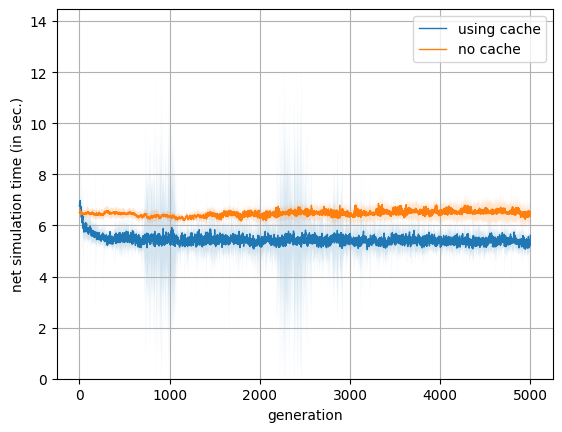

Total simulation time per generation:


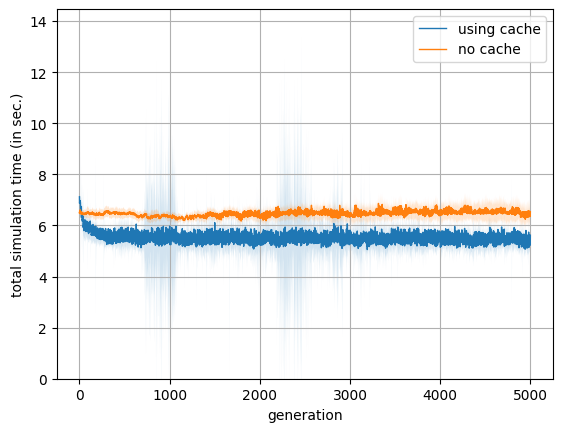

cumulative simulation time:


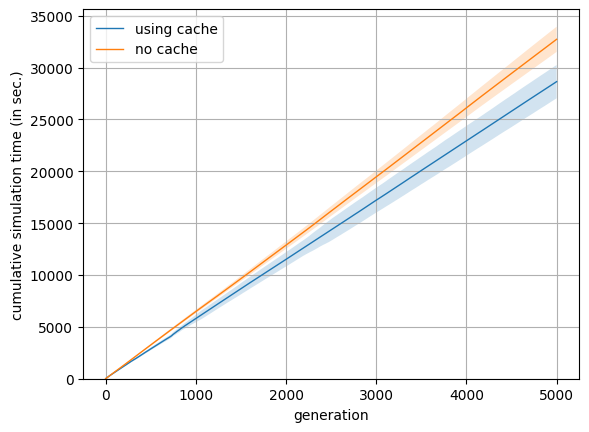

Total simulation time for 'using cache': 27372.687988 (-15.21%)
Total simulation time for 'no cache': 32283.583028999998 (-0.0%)


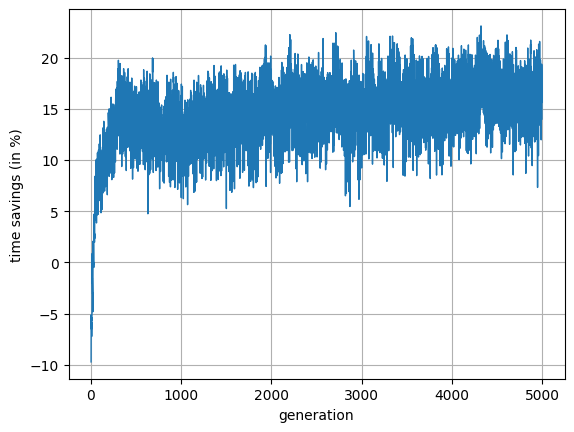

<Figure size 640x480 with 0 Axes>

In [50]:
printb("Net simulation time with 5 qubits:")
plot_net_simulation_time_per_generation(five_qubit_experiments, target_path="results/net_time_5q.png")

printb("Total simulation time per generation:")
plot_total_simulation_time_per_generation(five_qubit_experiments, target_path="results/total_time_5q.png")

printb("cumulative simulation time:")
plot_cumulative_simulation_time_per_generation(five_qubit_experiments, target_path="results/cum_time_5q.png") 
print_cumulative_simulation_time(five_qubit_experiments, reference=five_qubit_experiments[1])

plot_time_savings_per_generation([five_qubit_experiments[0]], no_cache_experiment=five_qubit_experiments[1], target_path="results/saved_time_5q.png")

Redundancy:


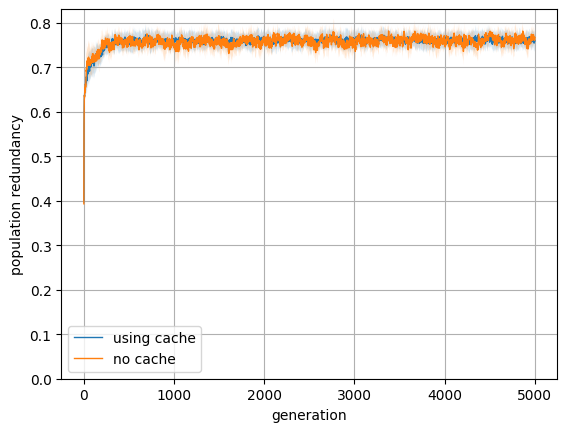

Mean redundancy for 'using cache': 0.7582078004105479
Mean redundancy for 'no cache': 0.7566294647086689


<Figure size 640x480 with 0 Axes>

In [51]:
printb("Redundancy:")
plot_redundancy_per_generation(five_qubit_experiments)
print_redundancy(five_qubit_experiments)

### 6 Qubits

In [52]:
six_qubit_experiments = filter_experiments(experiments, filter_params={
    "qubit_num": 6,
    "gate_count": 20,
    "merging_rounds": 10,
    "cache_rebuild_frequency": 10,
    "cache_size": 100,
    "target": "random",
    "selection_strategy": "roulette"
}) + filter_experiments(experiments, filter_params={
    "qubit_num": 6,
    "gate_count": 20,
    "merging_rounds": 0,
    "cache_rebuild_frequency": 1,
    "cache_size": 0,
    "target": "random",
    "selection_strategy": "roulette"
})

six_qubit_experiments = six_qubit_experiments[1:] # TODO: Once experiments are done, fix jsons and remove this line.

set_labels(six_qubit_experiments, label_function=rebuild_qubit_count_label)

print("Seed counts per config: ")
for experiment in six_qubit_experiments:
    print(f"\t{experiment.label}: {len(experiment.seeds)} seeds")



Seed counts per config: 
	using cache: 3 seeds
	using cache: 10 seeds
	no cache: 15 seeds


Net simulation time with 6 qubits:


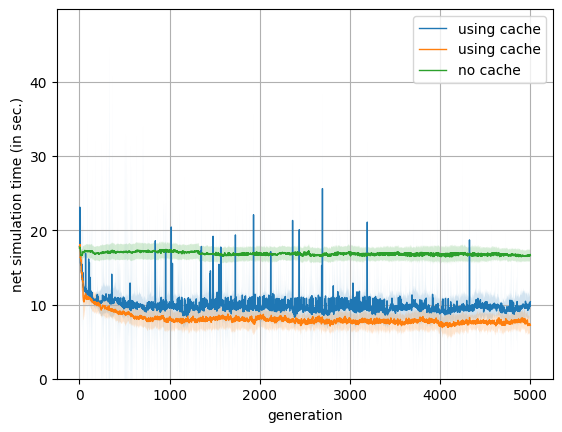

Total simulation time per generation:


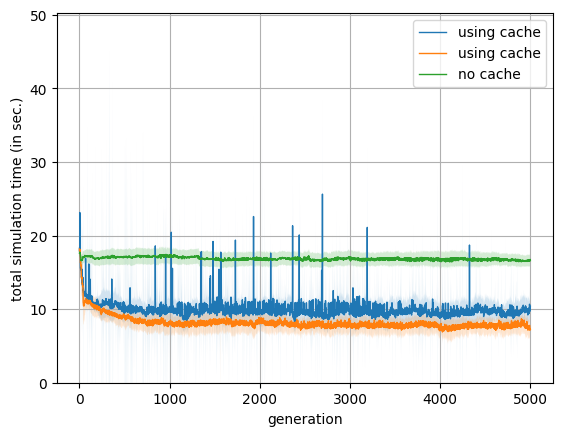

cumulative simulation time:


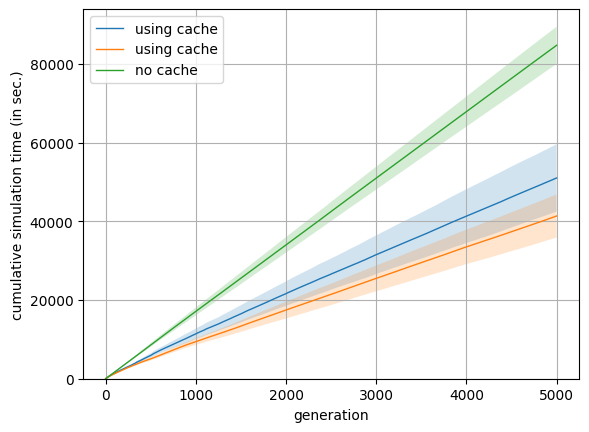

Total simulation time for 'using cache': 49127.693956 (--21.13%)
Total simulation time for 'using cache': 40558.8343145 (-0.0%)
Total simulation time for 'no cache': 84330.718069 (--107.92%)


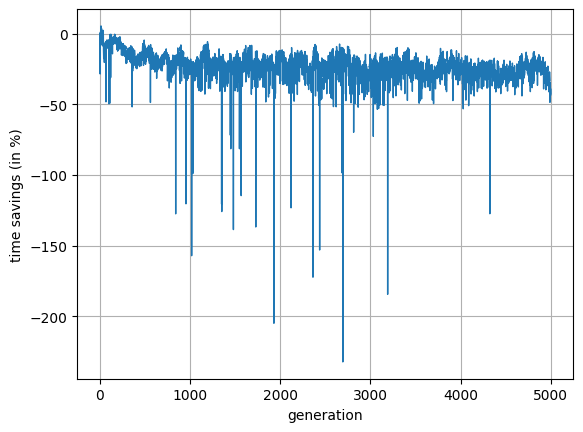

<Figure size 640x480 with 0 Axes>

In [53]:
printb("Net simulation time with 6 qubits:")
plot_net_simulation_time_per_generation(six_qubit_experiments, target_path="results/net_time_6q.png")

printb("Total simulation time per generation:")
plot_total_simulation_time_per_generation(six_qubit_experiments, target_path="results/total_time_6q.png")

printb("cumulative simulation time:")
plot_cumulative_simulation_time_per_generation(six_qubit_experiments, target_path="results/cum_time_6q.png") 
print_cumulative_simulation_time(six_qubit_experiments, reference=six_qubit_experiments[1])

plot_time_savings_per_generation([six_qubit_experiments[0]], no_cache_experiment=six_qubit_experiments[1], target_path="results/saved_time_6q.png")


Redundancy:


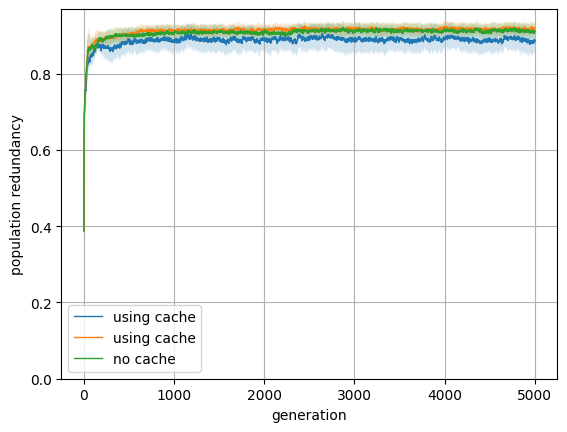

Mean redundancy for 'using cache': 0.886561271645876
Mean redundancy for 'using cache': 0.9121704247591979
Mean redundancy for 'no cache': 0.9071557976735618


<Figure size 640x480 with 0 Axes>

In [54]:
printb("Redundancy:")
plot_redundancy_per_generation(six_qubit_experiments)
print_redundancy(six_qubit_experiments)

### 7 Qubits

In [55]:
seven_qubit_experiments = filter_experiments(experiments, filter_params={
    "qubit_num": 7,
    "gate_count": 20,
    "merging_rounds": 10,
    "cache_rebuild_frequency": 10,
    "cache_size": 100,
    "target": "random",
    "selection_strategy": "roulette",
    "tag": "varying_qubit_count"
}) + filter_experiments(experiments, filter_params={
    "qubit_num": 7,
    "gate_count": 20,
    "merging_rounds": 0,
    "cache_rebuild_frequency": 1,
    "cache_size": 0,
    "target": "random",
    "selection_strategy": "roulette",
    "tag": "varying_qubit_count"
})

set_labels(seven_qubit_experiments, label_function=rebuild_qubit_count_label)

print("Seed counts per config: ")
for experiment in seven_qubit_experiments:
    print(f"\t{experiment.label}: {len(experiment.seeds)} seeds")



Seed counts per config: 
	using cache: 15 seeds
	no cache: 15 seeds


Net simulation time with 7 qubits:


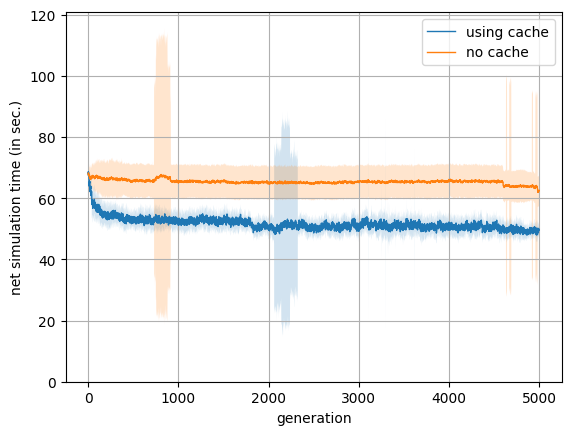

Total simulation time per generation:


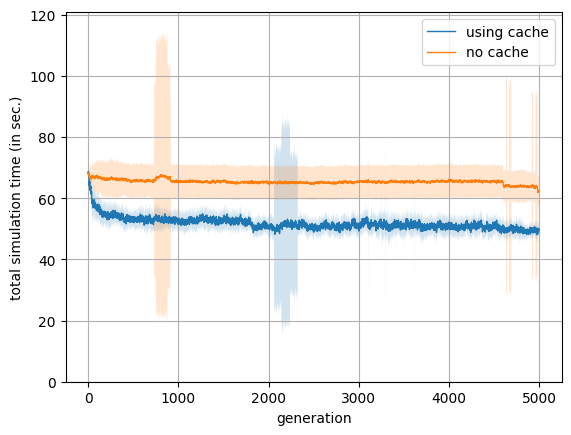

cumulative simulation time:


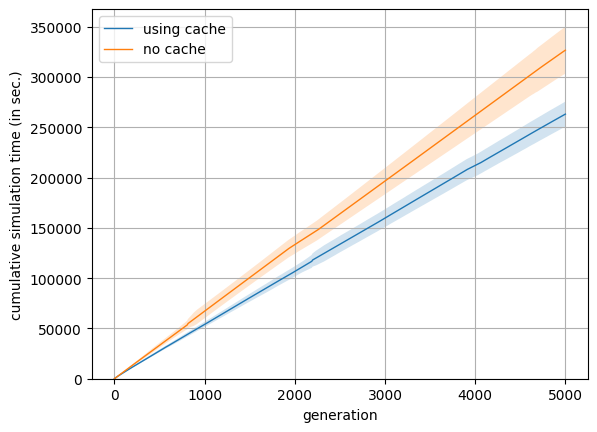

Total simulation time for 'using cache': 258724.45089500002 (-20.83%)
Total simulation time for 'no cache': 326781.922743 (-0.0%)


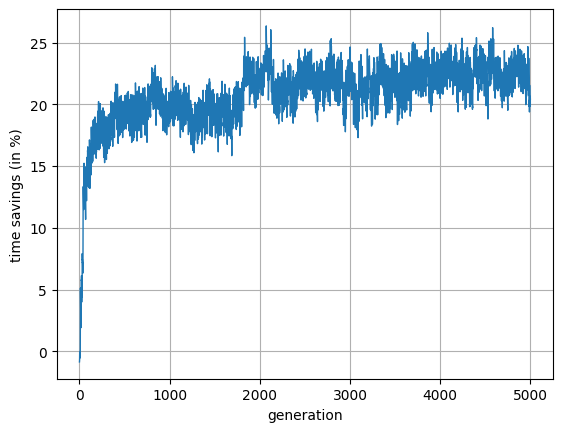

<Figure size 640x480 with 0 Axes>

In [56]:
printb("Net simulation time with 7 qubits:")
plot_net_simulation_time_per_generation(seven_qubit_experiments, target_path="results/net_time_7q.png")

printb("Total simulation time per generation:")
plot_total_simulation_time_per_generation(seven_qubit_experiments, target_path="results/total_time_7q.png")

printb("cumulative simulation time:")
plot_cumulative_simulation_time_per_generation(seven_qubit_experiments, target_path="results/cum_time_7q.png") 
print_cumulative_simulation_time(seven_qubit_experiments, reference=seven_qubit_experiments[1])

plot_time_savings_per_generation([seven_qubit_experiments[0]], no_cache_experiment=seven_qubit_experiments[1], target_path="results/saved_time_7q.png")

Redundancy:


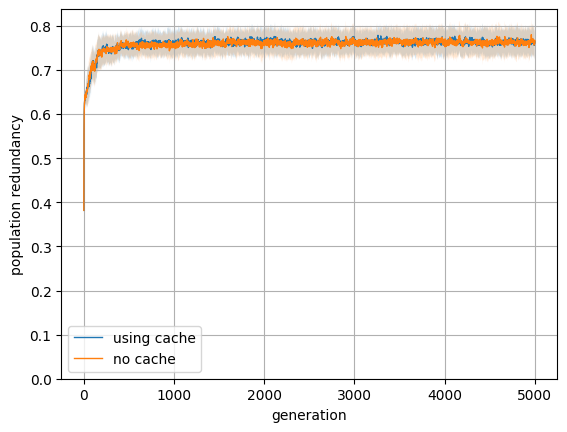

Mean redundancy for 'using cache': 0.7590521395862941
Mean redundancy for 'no cache': 0.7578739723143323


<Figure size 640x480 with 0 Axes>

In [57]:
printb("Redundancy:")
plot_redundancy_per_generation(seven_qubit_experiments)
print_redundancy(seven_qubit_experiments)

5 qubits


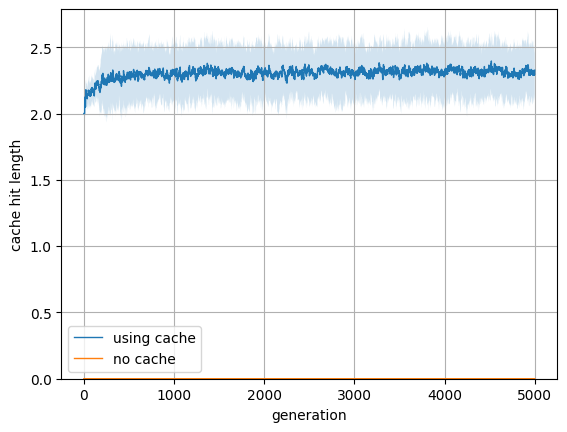

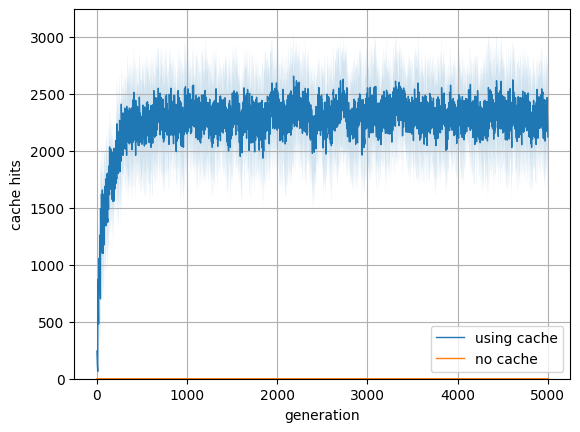

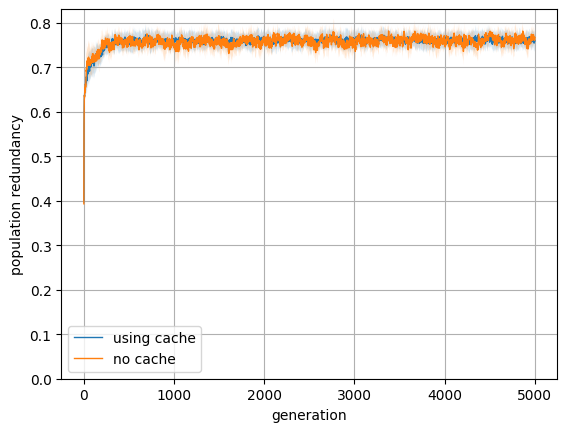

6 qubits


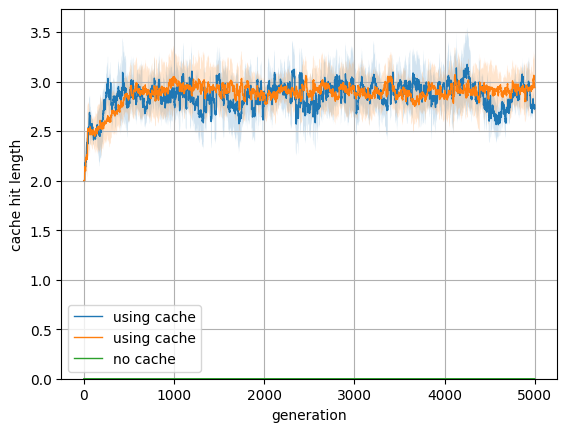

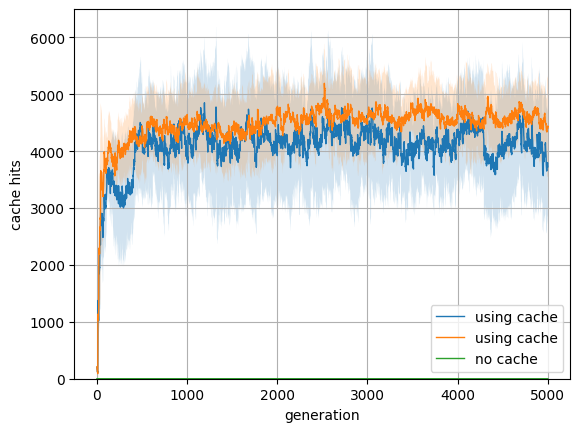

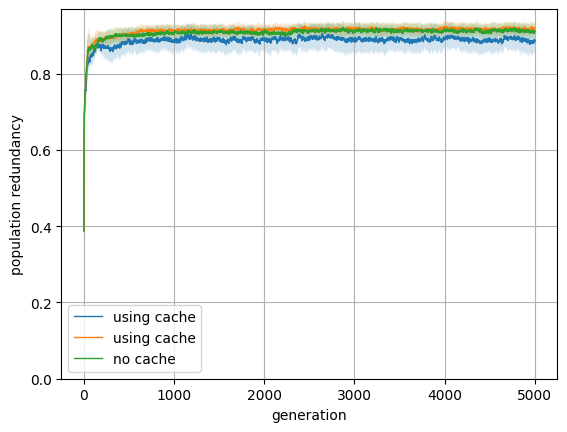

7 qubits


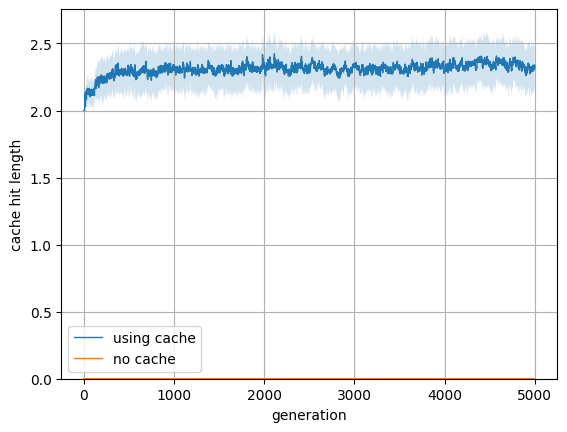

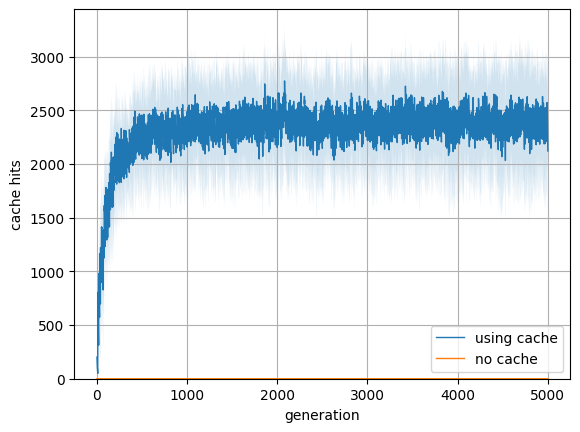

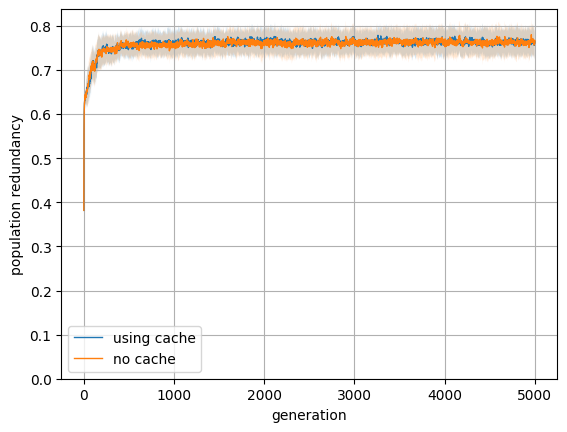

<Figure size 640x480 with 0 Axes>

In [58]:
printb("5 qubits")
plot_cache_hit_length_per_generation(five_qubit_experiments, target_path=None)
plot_cache_hits_per_generation(five_qubit_experiments, target_path=None)
plot_redundancy_per_generation(five_qubit_experiments, target_path=None)

printb("6 qubits")
plot_cache_hit_length_per_generation(six_qubit_experiments, target_path=None)
plot_cache_hits_per_generation(six_qubit_experiments, target_path=None)
plot_redundancy_per_generation(six_qubit_experiments, target_path=None)

printb("7 qubits")
plot_cache_hit_length_per_generation(seven_qubit_experiments, target_path=None)
plot_cache_hits_per_generation(seven_qubit_experiments, target_path=None)
plot_redundancy_per_generation(seven_qubit_experiments, target_path=None)

## RQ2 Ablation

### 5 Qubits

In [59]:
five_qubit_experiments = filter_experiments(experiments, filter_params={
    "qubit_num": 5,
    "gate_count": 20,
    "target": "random",
    "selection_strategy": "roulette",
    "tag": "qubit_ablation"
})

set_labels(five_qubit_experiments, label_function=rebuild_qubit_count_label)

print("Seed counts per config: ")
for experiment in five_qubit_experiments:
    print(f"\t{experiment.label}: {len(experiment.seeds)} seeds")



Seed counts per config: 
	using cache: 5 seeds
	no cache: 5 seeds


Time Savings:


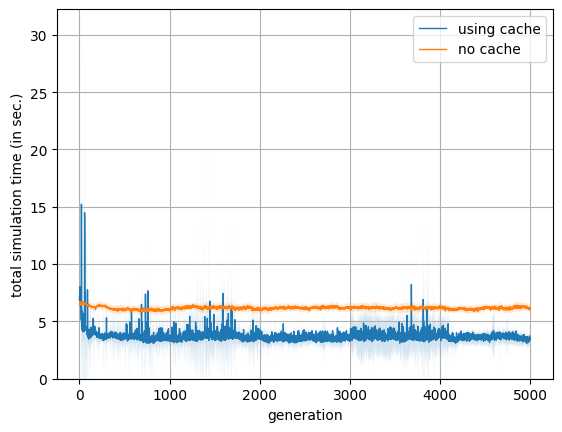

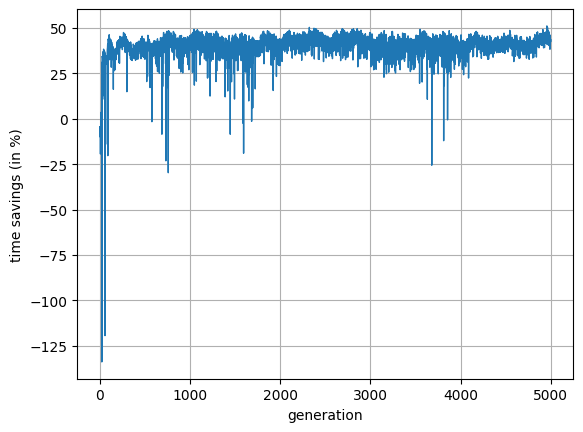

Total simulation time for 'using cache': 18240.249959 (-40.84%)
Total simulation time for 'no cache': 30833.985967 (-0.0%)


<Figure size 640x480 with 0 Axes>

In [60]:
printb("Time Savings:")

plot_total_simulation_time_per_generation(five_qubit_experiments)
plot_time_savings_per_generation(
    [five_qubit_experiments[0]], no_cache_experiment=five_qubit_experiments[1], target_path="results/saved_time_5q_ablation.png")
print_cumulative_simulation_time(five_qubit_experiments, five_qubit_experiments[1])

Cache hit length:


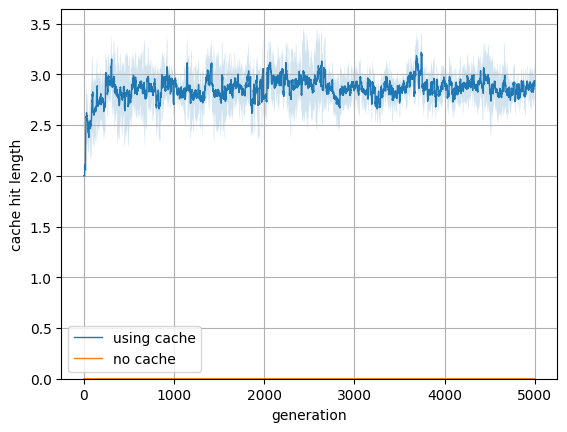

Total cache hits for 'using cache': 20121723.0
Mean cache hit length for 'using cache': 2.856979879333973


<Figure size 640x480 with 0 Axes>

In [61]:
printb("Cache hit length:")
plot_cache_hit_length_per_generation(five_qubit_experiments)
print_cumulative_cache_hits([five_qubit_experiments[0]])
print_avg_cache_hit_length([five_qubit_experiments[0]])

Redundancy:


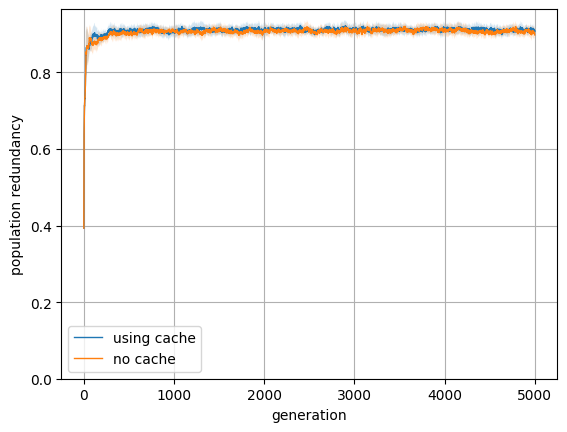

Mean redundancy for 'using cache': 0.9091854623927574
Mean redundancy for 'no cache': 0.9057999684193906


<Figure size 640x480 with 0 Axes>

In [62]:
printb("Redundancy:")
plot_redundancy_per_generation(five_qubit_experiments)
print_redundancy(five_qubit_experiments)

### 6 Qubits

In [63]:
six_qubit_experiments = filter_experiments(experiments, filter_params={
    "qubit_num": 6,
    "gate_count": 20,
    "merging_rounds": 10,
    "cache_rebuild_frequency": 10,
    "cache_size": 100,
    "target": "random",
    "selection_strategy": "roulette"
}) + filter_experiments(experiments, filter_params={
    "qubit_num": 6,
    "gate_count": 20,
    "merging_rounds": 0,
    "cache_rebuild_frequency": 1,
    "cache_size": 0,
    "target": "random",
    "selection_strategy": "roulette"
})

six_qubit_experiments = six_qubit_experiments[1:] # TODO: Once experiments are done, fix jsons and remove this line.

set_labels(six_qubit_experiments, label_function=rebuild_qubit_count_label)

print("Seed counts per config: ")
for experiment in six_qubit_experiments:
    print(f"\t{experiment.label}: {len(experiment.seeds)} seeds")



Seed counts per config: 
	using cache: 3 seeds
	using cache: 10 seeds
	no cache: 15 seeds


Time savings:


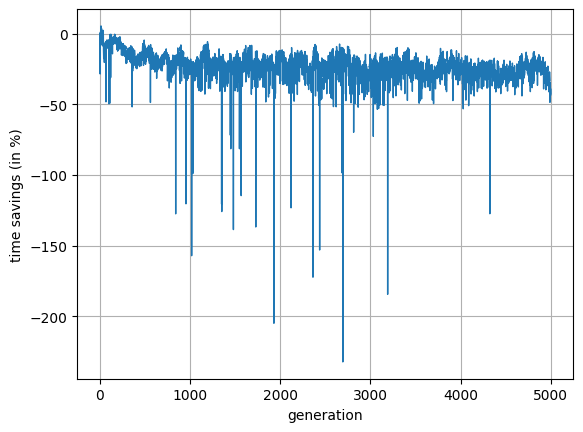

Total simulation time for 'using cache': 49127.693956 (--21.13%)
Total simulation time for 'using cache': 40558.8343145 (-0.0%)
Total simulation time for 'no cache': 84330.718069 (--107.92%)


<Figure size 640x480 with 0 Axes>

In [64]:
printb("Time savings:")
plot_time_savings_per_generation(
    [six_qubit_experiments[0]], no_cache_experiment=six_qubit_experiments[1], target_path="results/saved_time_6q_ablation.png")
print_cumulative_simulation_time(six_qubit_experiments, reference=six_qubit_experiments[1])

Cache hit length:


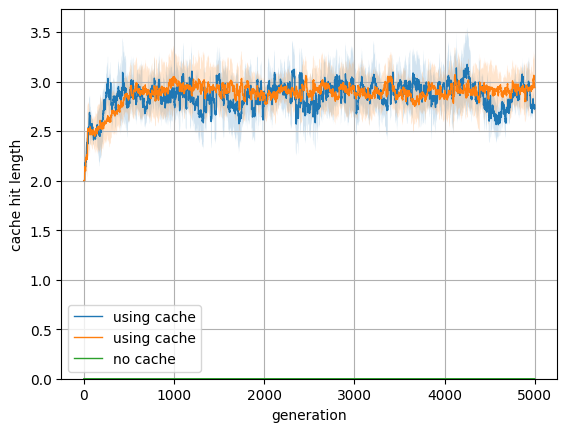

Total cache hits for 'using cache': 20439941.0
Mean cache hit length for 'using cache': 2.847901973225101


<Figure size 640x480 with 0 Axes>

In [65]:
printb("Cache hit length:")
plot_cache_hit_length_per_generation(six_qubit_experiments)
print_cumulative_cache_hits([six_qubit_experiments[0]])
print_avg_cache_hit_length([six_qubit_experiments[0]])

Redundancy:


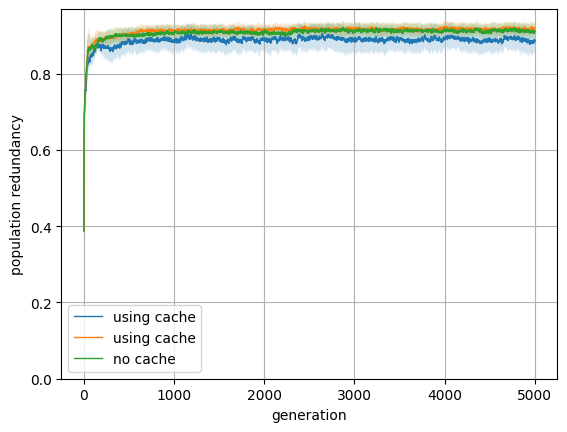

Mean redundancy for 'using cache': 0.886561271645876
Mean redundancy for 'using cache': 0.9121704247591979
Mean redundancy for 'no cache': 0.9071557976735618


<Figure size 640x480 with 0 Axes>

In [66]:
printb("Redundancy:")
plot_redundancy_per_generation(six_qubit_experiments)
print_redundancy(six_qubit_experiments)

### 7 Qubits

In [67]:
seven_qubit_experiments = filter_experiments(experiments, filter_params={
    "qubit_num": 7,
    "gate_count": 20,
    "target": "random",
    "selection_strategy": "roulette",
    "tag": "qubit_ablation"
})

set_labels(seven_qubit_experiments, label_function=rebuild_qubit_count_label)

print("Seed counts per config: ")
for experiment in seven_qubit_experiments:
    print(f"\t{experiment.label}: {len(experiment.seeds)} seeds")



Seed counts per config: 
	using cache: 5 seeds
	no cache: 5 seeds


Time savings:


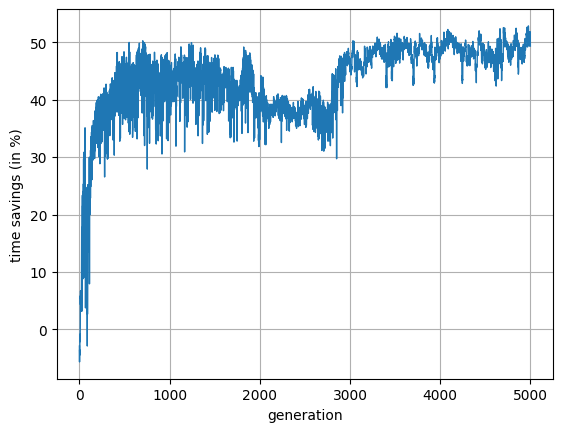

Total cache hits for 'using cache': 21335678.0
Total simulation time for 'using cache': 176893.834889 (-43.42%)
Total simulation time for 'no cache': 312656.666717 (-0.0%)


<Figure size 640x480 with 0 Axes>

In [68]:
printb("Time savings:")
plot_time_savings_per_generation(
    [seven_qubit_experiments[0]], no_cache_experiment=seven_qubit_experiments[1], target_path="results/saved_time_7q_ablation.png")
print_cumulative_cache_hits([seven_qubit_experiments[0]])
print_cumulative_simulation_time(seven_qubit_experiments, reference=seven_qubit_experiments[1])

Cache hit length:


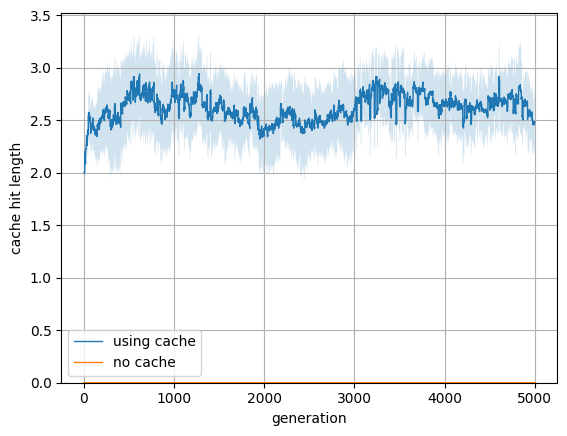

Total cache hits for 'using cache': 21335678.0
Mean cache hit length for 'using cache': 2.6181719730546704


<Figure size 640x480 with 0 Axes>

In [69]:
printb("Cache hit length:")
plot_cache_hit_length_per_generation(seven_qubit_experiments)
print_cumulative_cache_hits([seven_qubit_experiments[0]])
print_avg_cache_hit_length([seven_qubit_experiments[0]])

Redundancy:


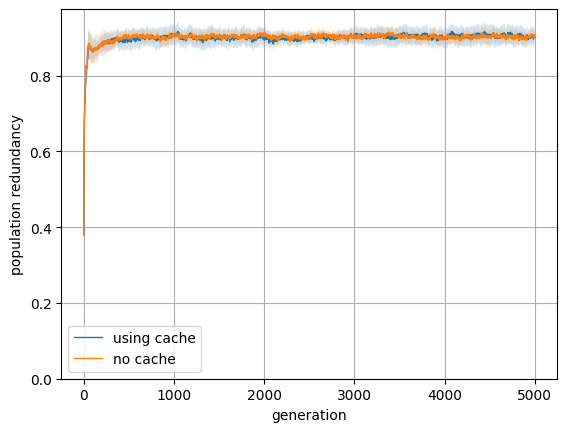

Mean redundancy for 'using cache': 0.89919042054845
Mean redundancy for 'no cache': 0.9002774882888575


<Figure size 640x480 with 0 Axes>

In [70]:
printb("Redundancy:")
plot_redundancy_per_generation(seven_qubit_experiments)
print_redundancy(seven_qubit_experiments)

## RQ 3: Different GA Setups and Synthesis Targets

### RQ3.1: Different GA Setups on Random Target

In [71]:
def rebuild_ga_setup_label(experiment: Experiment) -> str:
    return f"target = {experiment.target}, selection = {experiment.selection_strategy}"

In [72]:
random_unitary_experiments = filter_experiments(experiments, filter_params={
    "qubit_num": 6,
    "gate_count": 20,
    "merging_rounds": 10,
    "cache_rebuild_frequency": 10,
    "cache_size": 100,
    "target": "random",
}, sort_by="selection_strategy")

random_unitary_experiments = random_unitary_experiments[1:] # TODO: Once experiments are done, fix jsons and remove this line.

set_labels(random_unitary_experiments, label_function=rebuild_ga_setup_label)

print("Seed counts per config: ")
for experiment in random_unitary_experiments:
    print(f"\t{experiment.label}: {len(experiment.seeds)} seeds")



Seed counts per config: 
	target = random, selection = roulette: 3 seeds
	target = random, selection = roulette: 10 seeds
	target = random, selection = tournament: 11 seeds


Fitness for random unitary experiments


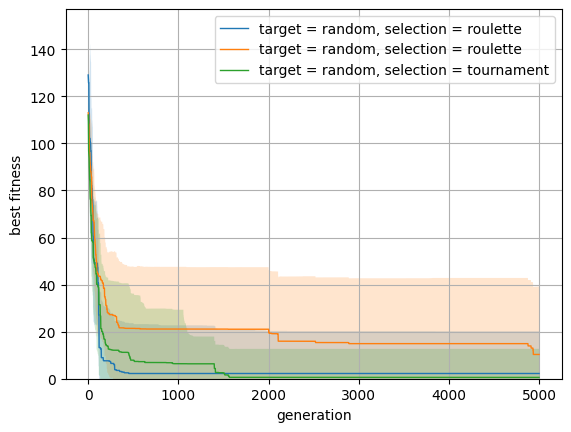

Redundancy of random unitary experiments


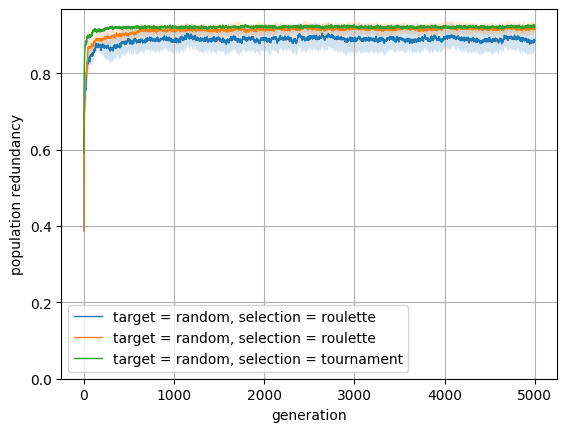

<Figure size 640x480 with 0 Axes>

In [73]:
# fitness scores and redundancies for different selection strategies
# on random target

printb("Fitness for random unitary experiments")
plot_fitness_per_generation(random_unitary_experiments, target_path="results/fitness_random_unitaries.png")

printb("Redundancy of random unitary experiments")
plot_redundancy_per_generation(random_unitary_experiments, target_path="results/redundancy_random_unitaries.png")


Simulation time of random unitary experiments


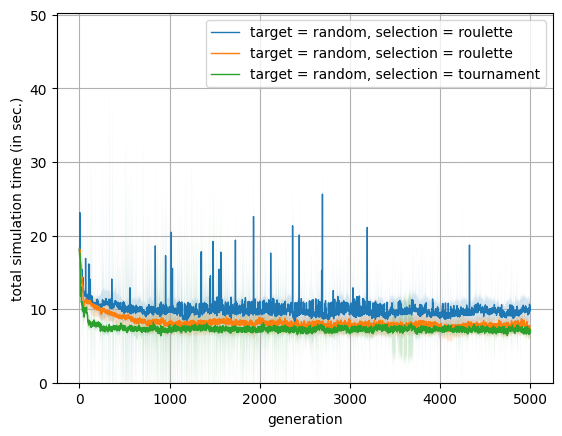

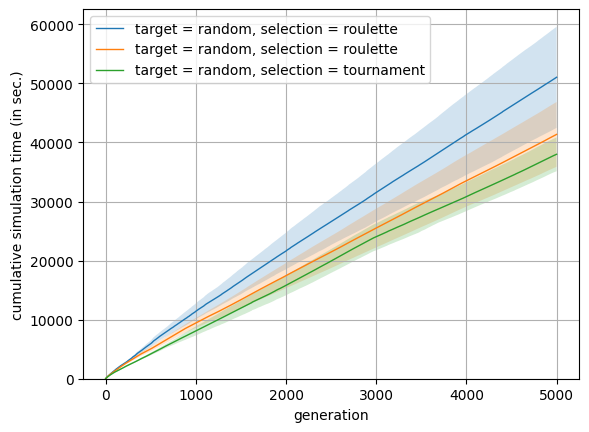

Total simulation time for 'target = random, selection = roulette': 49127.693956
Total simulation time for 'target = random, selection = roulette': 40558.8343145
Total simulation time for 'target = random, selection = tournament': 36519.952411000006


<Figure size 640x480 with 0 Axes>

In [74]:
# total simulation of both selection strategies on random target

printb("Simulation time of random unitary experiments")
plot_total_simulation_time_per_generation(random_unitary_experiments, target_path="results/total_time_random_unitaries.png")
plot_cumulative_simulation_time_per_generation(random_unitary_experiments, target_path="results/cum_time_random_unitaries.png")
print_cumulative_simulation_time(random_unitary_experiments)

Cache hits for random unitary experiments


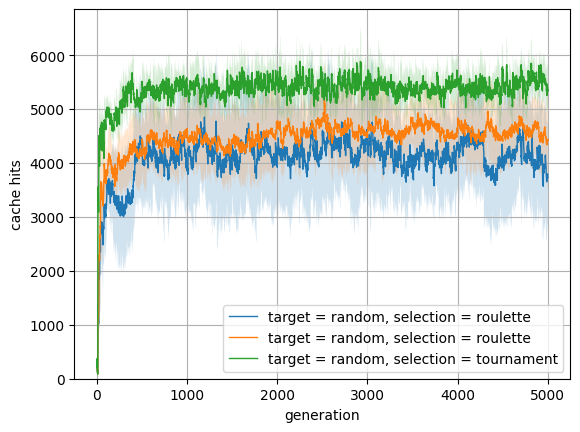

Cache hit length for random unitary experiments


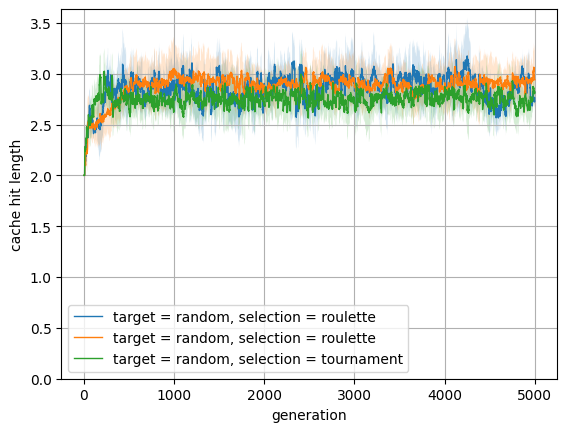

<Figure size 640x480 with 0 Axes>

In [75]:
printb("Cache hits for random unitary experiments")
plot_cache_hits_per_generation(random_unitary_experiments, target_path="results/hits_random_unitaries.png")

printb("Cache hit length for random unitary experiments")
plot_cache_hit_length_per_generation(random_unitary_experiments, target_path="results/hit_length_random_unitaries.png")

### RQ3.2: Different GA Setups on QFT Target

In [76]:
qft_experiments = filter_experiments(experiments, filter_params={
    "qubit_num": 6,
    "gate_count": 20,
    "merging_rounds": 10,
    "cache_rebuild_frequency": 10,
    "cache_size": 100,
    "target": "qft",
}, sort_by="selection_strategy")

set_labels(qft_experiments, label_function=rebuild_ga_setup_label)

print("Seed counts per config: ")
for experiment in qft_experiments:
    print(f"\t{experiment.label}: {len(experiment.seeds)} seeds")



Seed counts per config: 
	target = qft, selection = roulette: 6 seeds
	target = qft, selection = tournament: 15 seeds


Fitness for QFT experiments


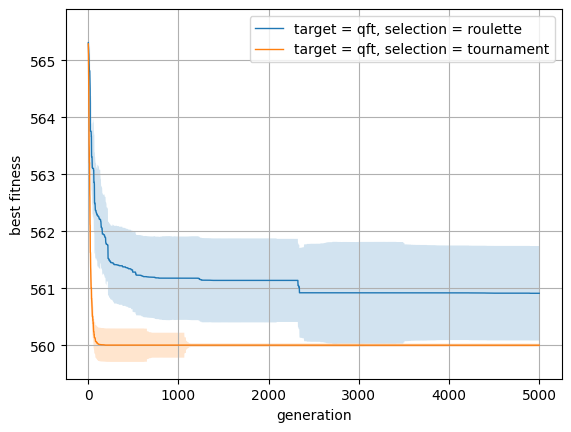

Redundancy of QFT experiments


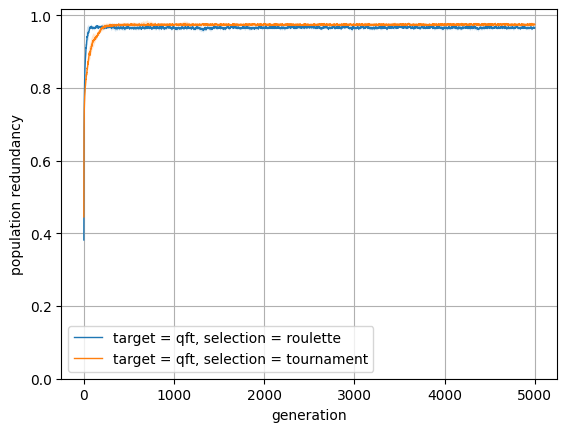

<Figure size 640x480 with 0 Axes>

In [77]:
# fitness scores and redundancies for different selection strategies
# on qft target

printb("Fitness for QFT experiments")
plot_fitness_per_generation(qft_experiments, anchor_yaxis=False, target_path="results/fitness_qft.png")
printb("Redundancy of QFT experiments")
plot_redundancy_per_generation(qft_experiments, target_path="results/redundancy_qft.png")

Simulation time of QFT experiments


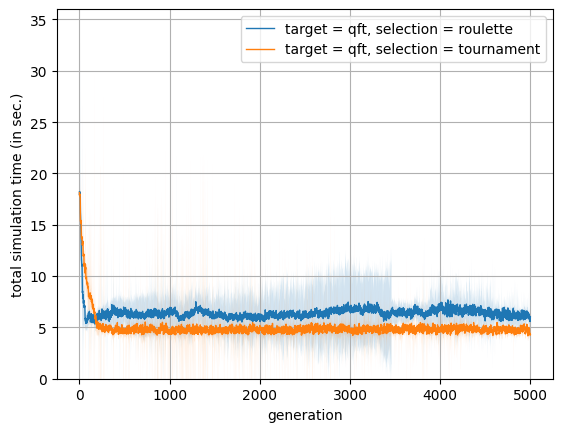

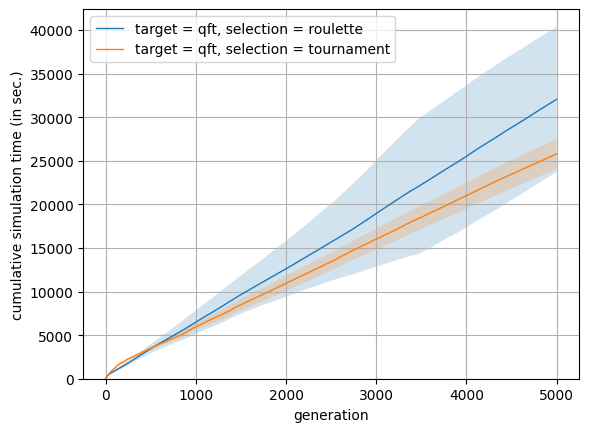

Total simulation time for 'target = qft, selection = roulette': 31766.513436 (-0.0%)
Total simulation time for 'target = qft, selection = tournament': 24589.988245 (-22.59%)


<Figure size 640x480 with 0 Axes>

In [78]:
# total simulation of both selection strategies on qft target
printb("Simulation time of QFT experiments")
plot_total_simulation_time_per_generation(qft_experiments, target_path="results/total_time_qft.png")
plot_cumulative_simulation_time_per_generation(qft_experiments, target_path="results/cum_time_qft.png")
print_cumulative_simulation_time(qft_experiments, reference=qft_experiments[0])

Cache hits for qft experiments


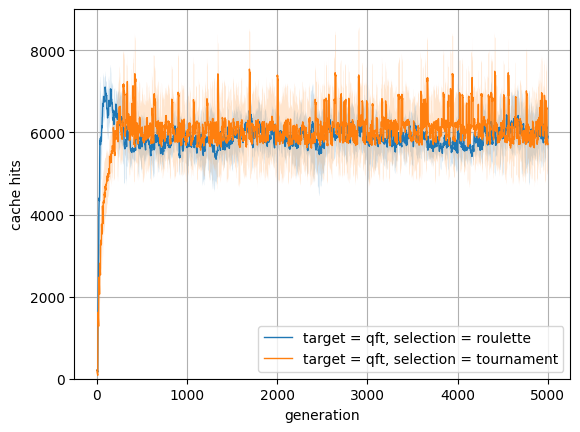

Cache hit length for qft experiments


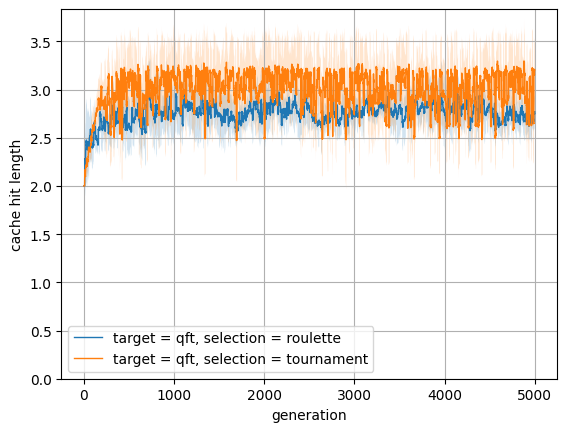

<Figure size 640x480 with 0 Axes>

In [79]:
printb("Cache hits for qft experiments")
plot_cache_hits_per_generation(qft_experiments, target_path="results/hits_qft.png")

printb("Cache hit length for qft experiments")
plot_cache_hit_length_per_generation(qft_experiments, target_path="results/hit_length_qft.png")
